# Pulse Planning Example for ITER with TokaMaker_TORAX

v0 2026-05-06 F. Sheehan - File creation

This notebook is an example pulse simulation using TokaMaker and TORAX coupled workflow. TokaMaker is used to solve time-independent equilibria and TORAX solves the 1-D transport equations to evolve the kinetic and current profiles throughout the pulse. Results from the codes are passed back and forth for several loops.

This example should serve as an introduction to the workflow. The inputs are based on Budney et al. 2008 Nuclear Fusion, but are not intended to be exact or in any way an ideal ITER shot.

## Seed eqdsk creation with TokaMaker

The first step is to create initial (AKA seed) equilibria. These are target shapes that are then interpolated between for the first TORAX run.

Notes:
- The first equilibrium's `psi_lcfs` value is critical — it will initialize the TORAX psi target. Following psi values are overwritten after the first TORAX run by its output.
- The shapes of these equilibria will be linearly interpolated between for all TokaMaker_TORAX timepoints. The LCFS geometry targets are never changed or evolved by TokaMaker_TORAX.

This first cell sets global shape targets. In this ITER geometry, the magnetic axis is at Z=0.5 m.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [2]:
# Global inputs
R0 = 6.3 # m, geometric center of the device
B0 = 5.2 # T, toroidal magnetic field at center of the device
Z0 = 0.5 # m, center of ITER plasma is at +0.5 m on this grid

Initialize the OpenFUSIONToolkit (OFT) and TokaMaker objects and setup the mesh using the loaded ITER mesh (`ITER_mesh.h5`).

In [3]:
# OFT setup
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.pulse_design import TokaMaker_TORAX
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_power_flux_fun, create_isoflux
import numpy as np
import matplotlib.pyplot as plt
import os
cwd = os.getcwd()

myOFT = OFT_env(nthreads=4)
mygs = TokaMaker(myOFT)

mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('ITER_mesh.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.settings.maxits=100
mygs.setup(order = 2, F0 = R0*B0)

mygs.set_coil_vsc({'VS': 1.0})

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Release version:  v26.6

Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    4

Linear Algebra backend: native

#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  2.859E+02
    # of points  =    4757
    # of edges   =   14156
    # of cells   =    9400
    # of boundary points =     112
    # of boundary edges  =     112
    # of boundary cells  =     112
  Resolution statistics:
    hmin =  9.924E-03
    hrms =  2.826E-01
    hmax =  8.466E-01
  Surface grounded at vertex     870


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    2.5839999999999999E-0

Set up the coil bounds. For this example all poloidal field (PF) and center stack (CS) coils are given $\pm$ 50 MA limits, which are likely much higher than the actual limits. Loose limits are used to prevent the non-convergence of TokaMaker due to coils hitting their limits. These coil limits will also be used for the TokaMaker_TORAX simulation later.

In [4]:
# Set coil bounds
coil_bounds = {key: [-50.E6, 50.E6] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

# function to build regularization terms for coil currents for initial equilibrium solves.
def build_min_norm_coil_reg(mygs):
    """Mild regularization to keep currents reasonable without targeting specific coils."""
    reg_terms = []
    for name in mygs.coil_sets:
        if name.startswith('CS'):
            weight = 2.E-2 if name.startswith('CS1') else 1.E-2
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=weight))
        elif name.startswith('PF'):
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.E-2))
        elif name.startswith('VS'):
            reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.E-2))
    reg_terms.append(mygs.coil_reg_term({'#VSC': 1.0}, target=0.0, weight=1.E2))
    mygs.set_coil_reg(reg_terms=reg_terms)

Make initial guesses at the $FF'$ and $p'$ profiles for the initial equilibria. These are not critical because after one loop of TokaMaker_TORAX, these will be overwritten using the kinetic profiles generated by TORAX.

In [5]:
# Make initial FF' and p' profiles for initial equilibria
ffp_prof = create_power_flux_fun(40,1.5,2.0)
pp_prof = create_power_flux_fun(40,4.0,1.0)
mygs.set_profiles(ffp_prof=ffp_prof,pp_prof=pp_prof)

Set up lists of targets for the initial equilibria. The lists are iterated through to create the initial equilibria, and eqdsks are saved. 

The five equilibria here is a bare minimum example. Adding more equilibria (and more shapes) can improve the evolution of the pulse. For example, a more careful shape evolution during startup can achieve better results (lower flux consumption, early diversion with desired strike-points). Shape targets produced by these initial equilibria are never evolved/iterated by TokaMaker_TORAX. 

In [6]:
# Make Ip and pax targets
Ip_targets = [1.5e6, 5e6, 15e6, 15e6, 1.5e6]
# pax = pressure on axis
# pax targets calculated from Budney et al. 2008 plots
pax_initial = 2 * 1e19 * 1e3 * 1.602e-19
pax_final = 2 * 1e20 * 12.5e3 * 1.603e-19
pax_targets = [pax_initial, 0.3*pax_initial, pax_final, pax_final, pax_initial]

Note about the `target_psi_lcfs`: The first value in the list (for the `i=0` seed equilibrium) is the most important. This will initialize TORAX for each loop of TokaMaker_TORAX. Currently this value is estimated to be as high as possible with CS currents as close to maximum as possible while still achieving the shape target. 

The other values should reasonable estimates to ensure that the shape targets are achievable within the PF/CS current limits. These values will be overwritten by TORAX after the first loop.

In [7]:
# Set shape targets
a = [1, 2, 2, 2, 1]
kappa = [1, 1.3, 1.8, 1.8, 1]
delta = [0, 0, 0, 0, 0]
diverted = [False, False, True, True, False]
x_points = np.array([[5.125, -3.4],])
diverted_isoflux_pts =np.array([
    [ 8.20,  0.41],
    [ 8.06,  1.46],
    [ 7.51,  2.62],
    [ 6.14,  3.78],
    [5.1   ,  3.72],
    [ 4.51,  3.02],
    [ 4.26,  1.33],
    [ 4.28,  0.08],
    [ 4.49, -1.34],
    [ 7.28, -1.89],
    [ 8.00, -0.68]
])
target_psi_lcfs = [+20, +13, +10, 0, +5] # Wb/rad targets for LCFS flux. Only the first value is used by TORAX, the others are overwritten after the first TORAX run.

The next cell loops through the lists above and produces the initial equilibria, then saves them as `.eqdsk` files to seed TokaMaker_TORAX.

For equilibria that are intended to be limited, the major radius is determined by `R = 3.9 + a[idx]` where 3.9 is the location of the inner limiting surface. No x-point targets are specified, but TokaMaker still sometimes finds diverted equilibria. This can be prevented by reducing the elongation or "pushing" the magnetic axis closer to the limiter surface. 

X-point targets are only applied it the equilibria is supposed to be diverted. `R0` is used for the major radius when diverted (set in the beginning of the notebook). 


Starting non-linear GS solver
     1  1.6325E+01  8.6335E-03  1.0975E-01  4.9582E+00  4.9992E-01  1.6378E-02
     2  1.9611E+01  4.6929E-03  2.4373E-02  4.9537E+00  4.9995E-01  1.6330E-02


/var/folders/0c/497qwkps0n92lm8mgp_t18800000gn/T/ipykernel_70357/4242223766.py:24: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(isoflux_pts, targets, weights=weights)


     3  2.0859E+01  4.0118E-03  5.7991E-03  4.9518E+00  4.9996E-01  1.6326E-02
     4  2.1396E+01  3.8137E-03  1.7336E-03  4.9509E+00  4.9997E-01  1.6326E-02
     5  2.1634E+01  3.7436E-03  6.7851E-04  4.9504E+00  4.9998E-01  1.6324E-02
     6  2.1740E+01  3.7162E-03  3.0064E-04  4.9501E+00  4.9998E-01  1.6324E-02
     7  2.1788E+01  3.7049E-03  1.4179E-04  4.9499E+00  4.9998E-01  1.6323E-02
     8  2.1810E+01  3.7001E-03  7.0774E-05  4.9498E+00  4.9998E-01  1.6322E-02
     9  2.1820E+01  3.6980E-03  3.7977E-05  4.9497E+00  4.9998E-01  1.6322E-02
    10  2.1825E+01  3.6971E-03  2.2013E-05  4.9497E+00  4.9998E-01  1.6322E-02
    11  2.1827E+01  3.6966E-03  1.3610E-05  4.9497E+00  4.9998E-01  1.6321E-02
    12  2.1828E+01  3.6965E-03  8.7827E-06  4.9496E+00  4.9998E-01  1.6321E-02
    13  2.1829E+01  3.6964E-03  5.8052E-06  4.9496E+00  4.9998E-01  1.6321E-02
    14  2.1829E+01  3.6963E-03  3.8882E-06  4.9496E+00  4.9998E-01  1.6321E-02
    15  2.1829E+01  3.6963E-03  2.6213E-06  4.9496E+

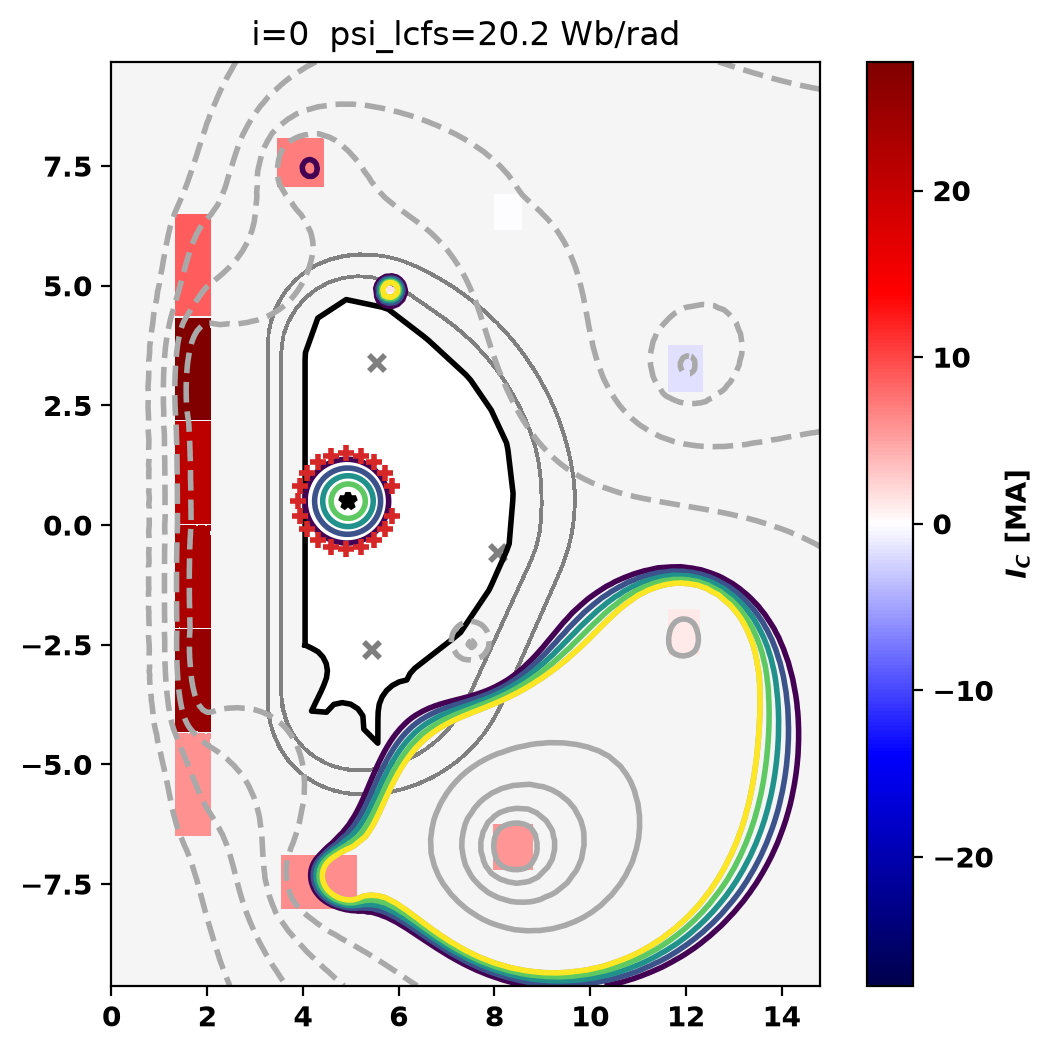

Saving gEQDSK: /Users/d22fish/Documents/7 Fusion Research/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/ITER/i=0.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    1.5000E+06
  Current Centroid [m]    =    4.920  0.500
  Magnetic Axis [m]       =    4.950  0.500
  Elongation              =    1.003 (U:  1.003, L:  1.003)
  Triangularity           =   -0.005 (U: -0.009, L: -0.002)
  Plasma Volume [m^3]     =   74.211
  q_0, q_95               =    1.214  3.249
  Plasma Pressure [Pa]    =   Axis:  3.2000E+03, Peak:  3.2000E+03
  Stored Energy [J]       =    1.1552E+05
  <Beta_pol> [%]          =    2.2093
  <Beta_tor> [%]          =    0.0059
  <Beta_n>   [%]          =    0.0228
  Diamagnetic flux [Wb]   =    2.0632E-02
  Toroidal flux [Wb]      =    1.6143E+01
  l_i                     =    1.2393
Starting non-linear GS solver
     1  1.1670E+01  5.9958E-04  1.2

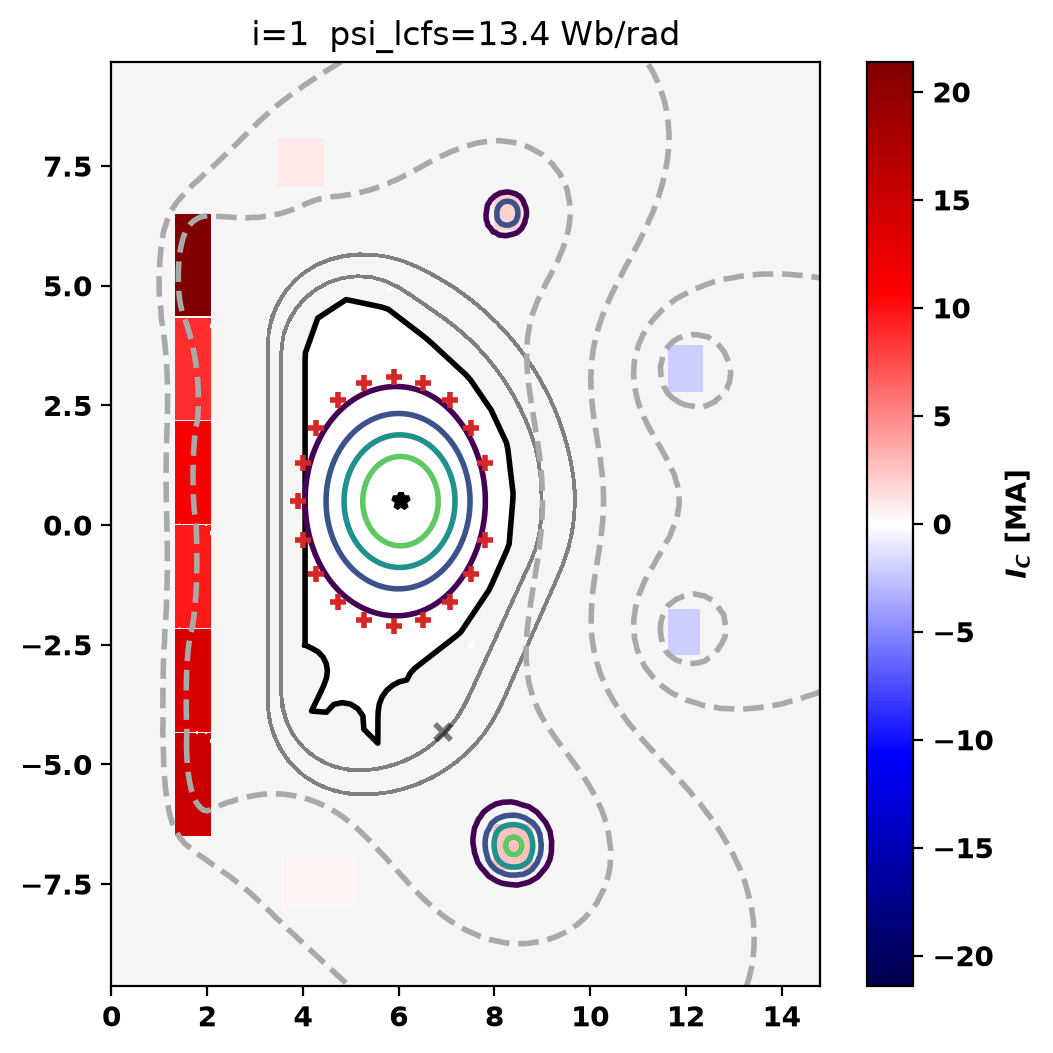

Saving gEQDSK: /Users/d22fish/Documents/7 Fusion Research/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/ITER/i=1.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    5.0000E+06
  Current Centroid [m]    =    5.931  0.500
  Magnetic Axis [m]       =    6.053  0.500
  Elongation              =    1.272 (U:  1.272, L:  1.272)
  Triangularity           =   -0.010 (U: -0.008, L: -0.012)
  Plasma Volume [m^3]     =   527.494
  q_0, q_95               =    1.447  4.437
  Plasma Pressure [Pa]    =   Axis:  9.6000E+02, Peak:  9.6000E+02
  Stored Energy [J]       =    2.4246E+05
  <Beta_pol> [%]          =    0.3545
  <Beta_tor> [%]          =    0.0025
  <Beta_n>   [%]          =    0.0052
  Diamagnetic flux [Wb]   =    2.7251E-01
  Toroidal flux [Wb]      =    8.0628E+01
  l_i                     =    1.2433
Starting non-linear GS solver


/var/folders/0c/497qwkps0n92lm8mgp_t18800000gn/T/ipykernel_70357/4242223766.py:14: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(diverted_isoflux_pts, targets, weights=weights)


     1  1.4057E+01  7.5937E-02  3.2817E-01  6.3804E+00  5.4265E-01 -1.0616E-03
     2  1.8907E+01  5.5282E-02  1.8489E-01  6.3623E+00  5.4783E-01 -9.1191E-04
     3  2.1118E+01  4.9120E-02  1.0871E-01  6.3525E+00  5.5116E-01 -8.1308E-04
     4  2.2315E+01  4.6650E-02  6.5882E-02  6.3473E+00  5.5326E-01 -7.3879E-04
     5  2.3009E+01  4.5467E-02  4.0765E-02  6.3447E+00  5.5452E-01 -6.8559E-04
     6  2.3424E+01  4.4834E-02  2.5394E-02  6.3433E+00  5.5524E-01 -6.4989E-04
     7  2.3676E+01  4.4473E-02  1.5845E-02  6.3426E+00  5.5563E-01 -6.2640E-04
     8  2.3829E+01  4.4261E-02  9.8747E-03  6.3422E+00  5.5583E-01 -6.1142E-04
     9  2.3923E+01  4.4134E-02  6.1399E-03  6.3420E+00  5.5591E-01 -6.0197E-04
    10  2.3981E+01  4.4056E-02  3.8116E-03  6.3418E+00  5.5594E-01 -5.9608E-04
    11  2.4016E+01  4.4009E-02  2.3627E-03  6.3418E+00  5.5594E-01 -5.9244E-04
    12  2.4037E+01  4.3981E-02  1.4652E-03  6.3417E+00  5.5592E-01 -5.9019E-04
    13  2.4051E+01  4.3963E-02  9.0924E-04  6.3417E+

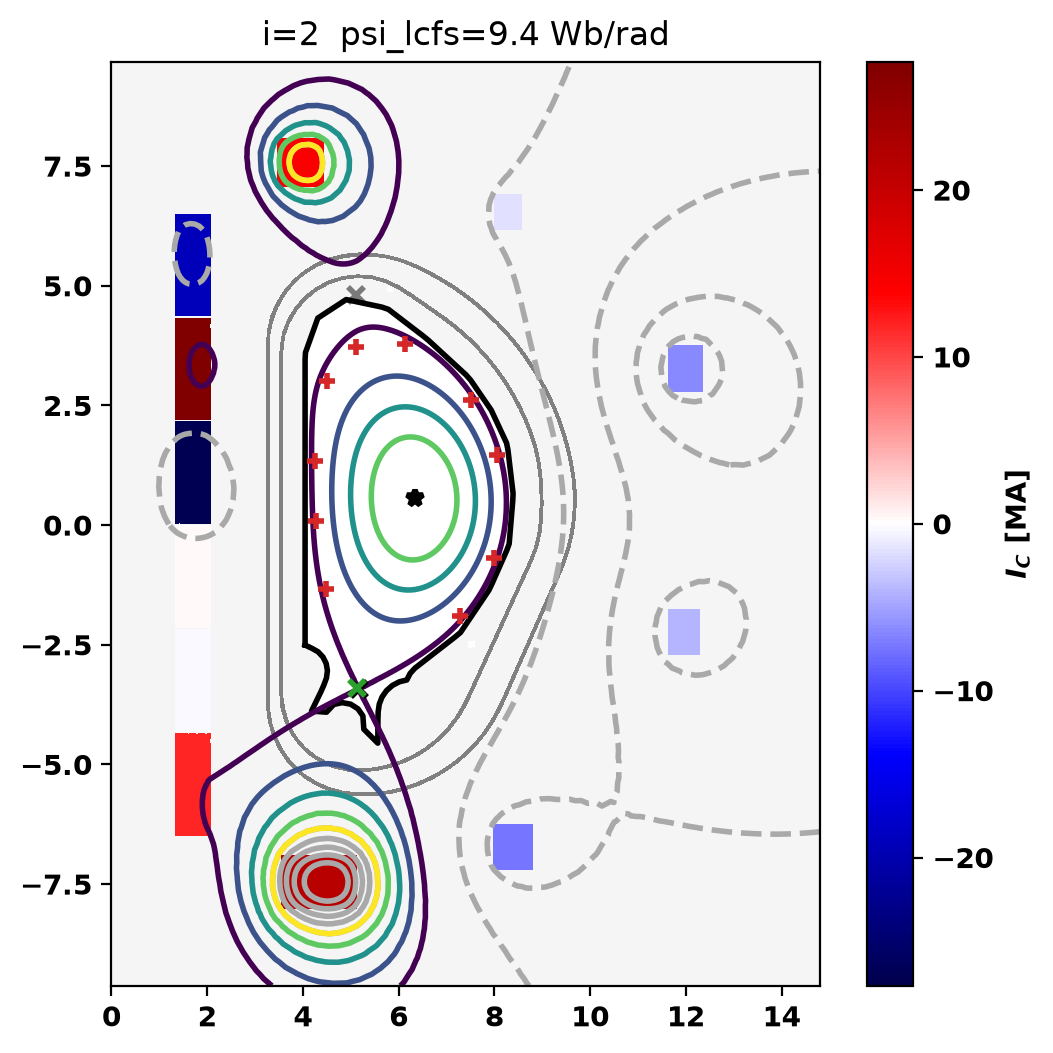

Saving gEQDSK: /Users/d22fish/Documents/7 Fusion Research/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/ITER/i=2.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    1.5000E+07
  Current Centroid [m]    =    6.173  0.562
  Magnetic Axis [m]       =    6.342  0.556
  Elongation              =    1.863 (U:  1.760, L:  1.967)
  Triangularity           =    0.439 (U:  0.367, L:  0.511)
  Plasma Volume [m^3]     =   867.968
  q_0, q_95               =    0.854  3.028
  Plasma Pressure [Pa]    =   Axis:  4.0025E+05, Peak:  4.0025E+05
  Stored Energy [J]       =    1.6327E+08
  <Beta_pol> [%]          =   30.7507
  <Beta_tor> [%]          =    1.1348
  <Beta_n>   [%]          =    0.8114
  Diamagnetic flux [Wb]   =    1.6676E+00
  Toroidal flux [Wb]      =    1.2966E+02
  l_i                     =    1.2135
Starting non-linear GS solver
     1  1.4228E+01  7.6841E-02  3

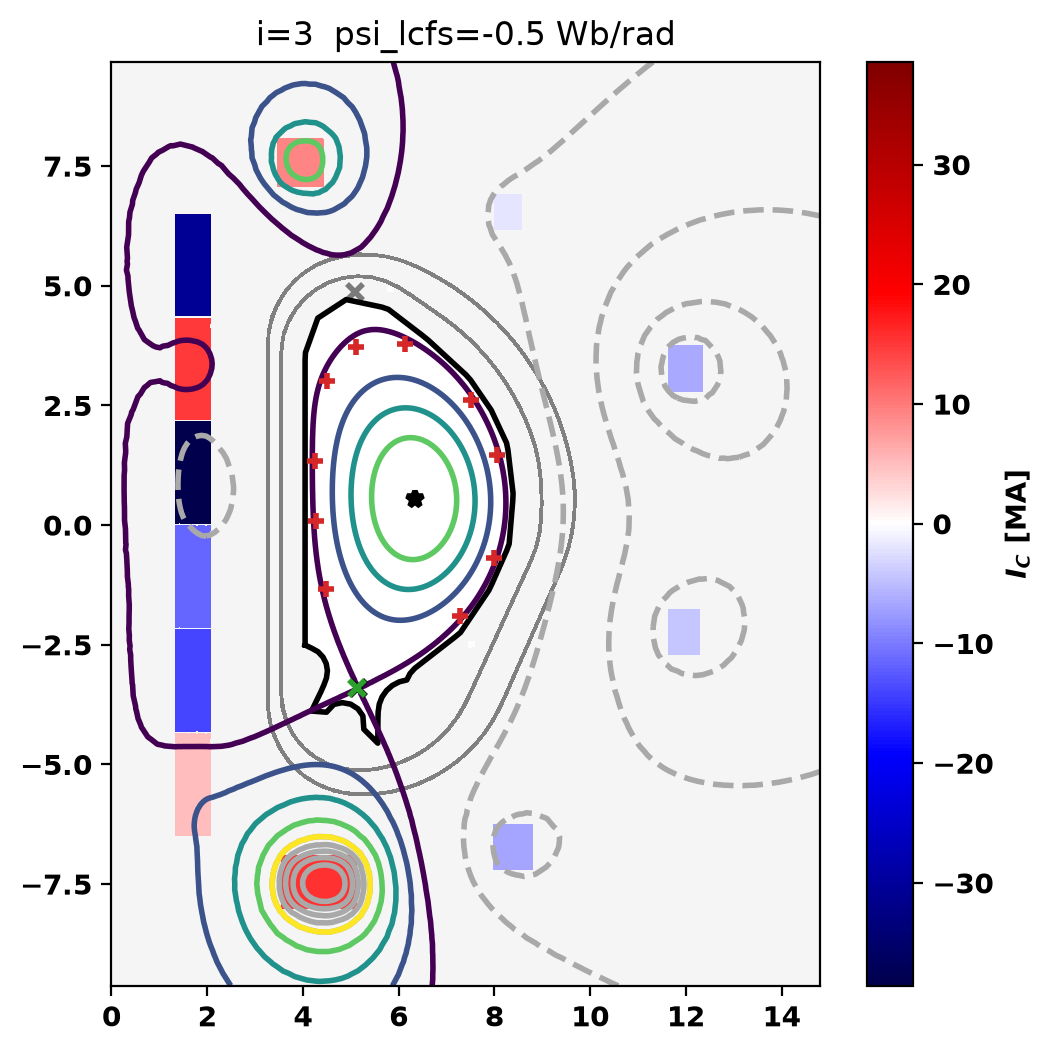

Saving gEQDSK: /Users/d22fish/Documents/7 Fusion Research/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/ITER/i=3.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    1.5000E+07
  Current Centroid [m]    =    6.176  0.556
  Magnetic Axis [m]       =    6.342  0.552
  Elongation              =    1.860 (U:  1.748, L:  1.972)
  Triangularity           =    0.436 (U:  0.354, L:  0.518)
  Plasma Volume [m^3]     =   855.400
  q_0, q_95               =    0.839  2.966
  Plasma Pressure [Pa]    =   Axis:  4.0025E+05, Peak:  4.0025E+05
  Stored Energy [J]       =    1.6090E+08
  <Beta_pol> [%]          =   30.2706
  <Beta_tor> [%]          =    1.1356
  <Beta_n>   [%]          =    0.8065
  Diamagnetic flux [Wb]   =    1.6805E+00
  Toroidal flux [Wb]      =    1.2750E+02
  l_i                     =    1.2142
Starting non-linear GS solver
     1  1.6350E+01  8.6461E-03  8

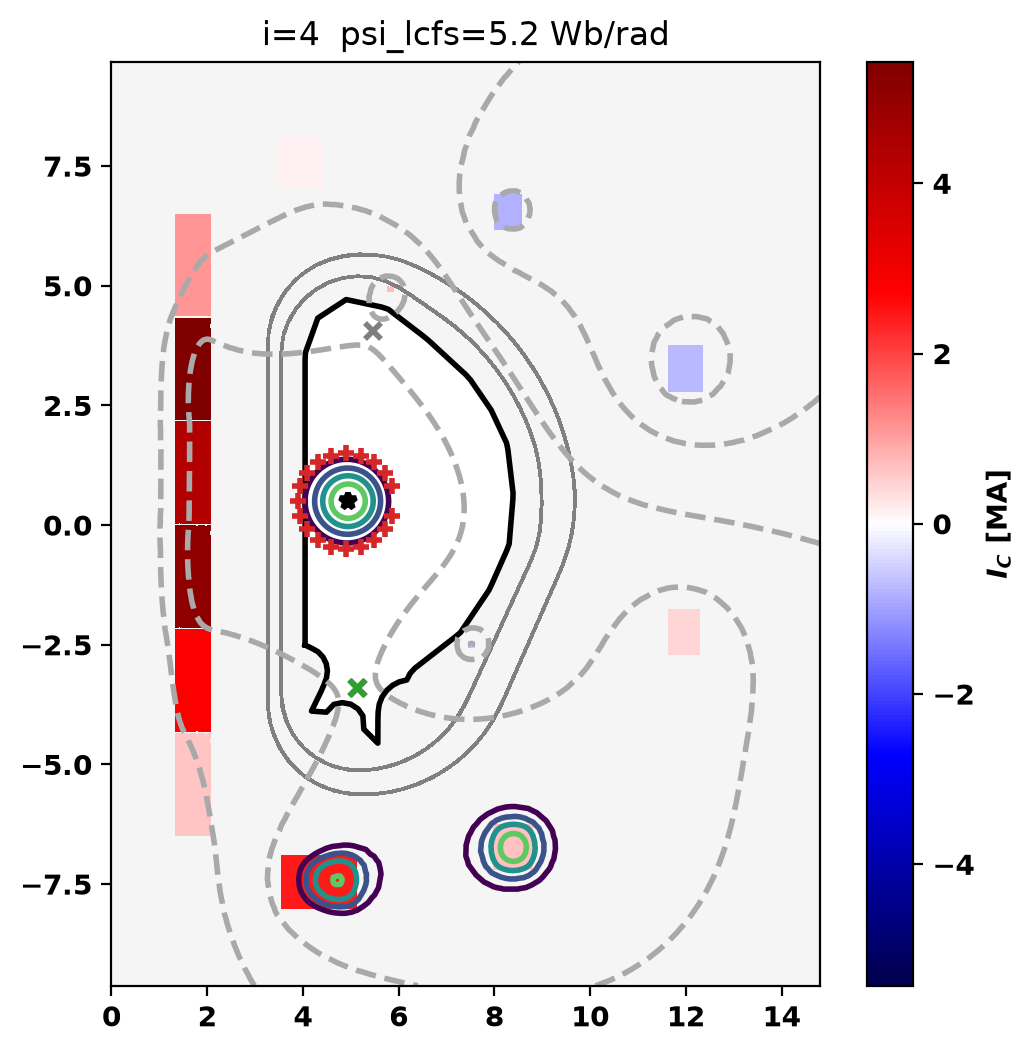

Saving gEQDSK: /Users/d22fish/Documents/7 Fusion Research/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/ITER/i=4.eqdsk
 Using COCOS=2...
Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    1.5000E+06
  Current Centroid [m]    =    4.920  0.500
  Magnetic Axis [m]       =    4.950  0.500
  Elongation              =    1.003 (U:  1.002, L:  1.003)
  Triangularity           =   -0.004 (U: -0.008, L: -0.001)
  Plasma Volume [m^3]     =   74.063
  q_0, q_95               =    1.212  3.244
  Plasma Pressure [Pa]    =   Axis:  3.2000E+03, Peak:  3.2000E+03
  Stored Energy [J]       =    1.1533E+05
  <Beta_pol> [%]          =    2.2107
  <Beta_tor> [%]          =    0.0059
  <Beta_n>   [%]          =    0.0228
  Diamagnetic flux [Wb]   =    2.0633E-02
  Toroidal flux [Wb]      =    1.6105E+01
  l_i                     =    1.2416


In [8]:
# Produce initial equilibria
psi_lcfs_results = []

for idx in range(len(a)):
    psi_lcfs_target = target_psi_lcfs[idx]

    if diverted[idx]:  # Flattop (mid-swing)
        R = R0
        mygs.set_saddle_constraints(x_points)
        mygs.set_isoflux_constraints(diverted_isoflux_pts)
        psi_lcfs_weight = 10
        targets = np.full(diverted_isoflux_pts.shape[0], psi_lcfs_target)
        weights = np.full(diverted_isoflux_pts.shape[0], psi_lcfs_weight)
        mygs.set_flux(diverted_isoflux_pts, targets, weights=weights)
    else:  # Ramp-up/down (pre-charged)
        R = 3.9 + a[idx]
        isoflux_pts = create_isoflux(20, R, Z0, a[idx], kappa[idx], delta[idx])
        mygs.set_isoflux_constraints(isoflux_pts)
        # set_flux_target_on_lcfs(mygs, isoflux_pts, psi_lcfs_target, weight=5.0)
        # build_coil_reg(mygs, cs_precharge_targets) # sets coil targets and regularization depending on phase
        psi_lcfs_weight = 10
        targets = np.full(isoflux_pts.shape[0], psi_lcfs_target)
        weights = np.full(isoflux_pts.shape[0], psi_lcfs_weight)
        mygs.set_flux(isoflux_pts, targets, weights=weights)

    build_min_norm_coil_reg(mygs)
    mygs.set_targets(Ip=Ip_targets[idx], pax=pax_targets[idx])

    mygs.init_psi(R, Z0, a[idx], kappa[idx], delta[idx])
    equil_object = mygs.solve()

    stats = mygs.get_stats()
    psi_lcfs = mygs.psi_bounds[0]
    psi_lcfs_results.append(psi_lcfs)
    coil_currents, _ = mygs.get_coil_currents()
    print(f'i={idx}: target psi_lcfs = {psi_lcfs_target:.2f} Wb/rad')
    print(f'      solved psi_lcfs = {psi_lcfs:.2f} Wb/rad  ({psi_lcfs*2*np.pi:.1f} Wb)')

    fig, ax = plt.subplots(1, 1)
    mygs.plot_machine(fig, ax, coil_colormap='seismic', coil_scale=1.E-6,
                      coil_clabel=r'$I_C$ [MA]', coil_symmap=True)
    mygs.plot_psi(fig, ax, plasma_nlevels=5, vacuum_nlevels=5)
    mygs.plot_constraints(fig, ax)
    ax.set_title(f'i={idx}  psi_lcfs={psi_lcfs:.1f} Wb/rad')
    plt.show()

    eqdsk_name = os.path.join(cwd, f'i={idx}.eqdsk')
    mygs.save_eqdsk(eqdsk_name, cocos=2, nr=500, nz=500) # saving at extremely high resolution to avoid issues with contour tracing package used by TORAX, only necessary for initial eqdkss, could possibly be lowered
    mygs.print_info()


## Setup full pulse simulation

The following cells set up the pulse planning simulation. This primarily involves creating the TORAX configuration, which is done with `tmtx.set_*` methods of the `TokaMaker_TORAX` object.

For advanced setups, a complete TORAX configuration (in the form of a dict) can be loaded into TokaMaker_TORAX using the `tmtx.load_TORAX_config` method. This example shows that TORAX can be configured solely with the `tmtx.set_*` methods. 

A few quick notes:
- Time dependent (scalar) inputs should be given in dict form, where the key is the time and the value is the input. Several examples are shown below. TORAX will linearly interpolate between data provided.
- The final time `t_final` for the TokaMaker_TORAX simulation can be smaller than times specified in the configuration. For example if an initial equilibria is set to 600 s, but `t_final` is set to 120 s, the shapes will be interpolated, then the simulation will only be run to 120 s, so this is not a problem. 
- `tm_times` determines the timepoints where TokaMaker_TORAX will produce TokaMaker equilibria during the simulation loop. These can be spaced evenly (as is currently done with `np.linspace`) or unevenly  to generate more equilibria around times of interest (e.g. during rampup). 
- `last_surface_factor` determines how close to the LCFS TORAX will attempt to trace contours when loading the eqdsks. This should be 0.99 or higher. If TokaMaker_TORAX is failing due to eqdsks not being accepted by TORAX, try increasing the resolution (`nr` and `nz` of the `TokaMaker.save_eqdsk` method used to save the initial/seed equilibria above).
- TokaMaker_TORAX requires the user to instantiate and setup the OFT environment and TokaMaker object, then pass the latter to the `TokaMaker_TORAX` object when initializing.

In [9]:

eqdsk_list = [os.path.join(cwd, 'i=0.eqdsk'),  # use initial eqdsk to start
              os.path.join(cwd, 'i=1.eqdsk'),  
              os.path.join(cwd, 'i=2.eqdsk'),  # start of flattop
              os.path.join(cwd, 'i=3.eqdsk'),  # end of flattop
              os.path.join(cwd, 'i=4.eqdsk')]  # use initial eqdsk as end of pulse

eqtimes = [0, 30, 80, 500, 600] # times corresponding to each initial eqdsk


t_final = 600
tmtx = TokaMaker_TORAX(
    t_init = 0,
    t_final = t_final,
    tx_dt = 1, # s, TORAX time step 
    eqtimes = eqtimes,
    g_eqdsk_arr = eqdsk_list,
    last_surface_factor = 0.99,
    tm_times = np.linspace(0, t_final, 25), # the times at which TokaMaker will solve equilibria
    tokamaker_obj = mygs, # passes existing OFT environment to TokaMaker_TORAX
)

`tmtx.set_TORAX_grid` is used to set the radial positions of the TORAX grid, in $\rho_{toroidal}$. This simulation uses uniform grid spacing, 51 points between $\rho_{toroidal} = 0$ and $1$. Non-uniform grid spacing is supported by TORAX and can be used with the `grid_type='face_centers'` and `grid=` specified locations of center of each computational cell.

In [10]:
# Set TORAX Grid, 51 points evenly spaced in rho_toroidal space (TORAX radial coordinate).
tmtx.set_TORAX_grid(grid_type='n_rho', grid=51)

Heating and density sources are specified. Total heating power is split between NBI and ECRH (both of which heat and produce non-inductive current). The $\rho_{tor}$ location of heating deposition is specified, and the TORAX default values for the width of the Gaussian is used. Total heating power estimates for this pulse are based on Budny 2008 NF. The `nbi_current` input tells TokaMaker_TORAX to apply a current source using a ratio of NBI heating power to driven current of 1 W per 16e6 MA. 

Other sources are enabled by default but can be turned off, including fusion power and electron-ion momentum exchange.

Gas puffing is enabled with estimated values. Pellet deposition is also available, by specifying a particle source, a location, and a Gaussian width. Use a time dependent dict for the particle source amount `S_total` to determine when fueling should be applied. Both fueling sources are set using `set_fueling`.

In [11]:
# Heating (Budney 2008 NF: ~33 MW NBI + ~20 MW ECRH at flattop = ~53 MW total)
# ECRH-assisted startup: ECRH on early in current ramp to raise Te, reduce Vloop.

# ECRH: on during ramp-up for assisted startup, continues through flattop and partway into rampdown
ecrh_powers = {
    0:    0,
    10:    0,
    50:   20.0E6,    # ECRH-assisted startup (Budney 2008: ~20 MW during ramp-up)
    80:   20.0E6,    # L-H transition; ECRH stays at 20 MW
    450:  20.0E6,    # End of flattop
    500:  15.0E6,    # Start rampdown
    520:  10.0E6,
    540:   5.0E6,
    560:   0,
    600:   0,
}

# NBI: turns on at L-H transition when plasma is sufficiently dense (Budney 2008: ~33 MW)
generic_powers = {
    0:    0,
    79:   0,
    80:   33.0E6,    # NBI on at L-H transition
    450:  33.0E6,    # End of flattop
    500:  15.0E6,    # Start rampdown
    520:  10.0E6,
    540:   7.0E6,
    560:   4.0E6,
    580:   2.0E6,
    600:   0,
}

tmtx.set_heating(generic_heat=generic_powers, generic_heat_loc=0.25, nbi_current=True, ecrh=ecrh_powers, ecrh_loc=0.35)

tmtx.set_fueling(gas_puff_S_total=1e22, gas_puff_decay_length=0.05, pellet_deposition_location=0.8, pellet_width=0.1, pellet_S_total={0: 0, 90: 5e21, 450: 5e21, 451: 0}) # estimations based on budney2008

This cell produces initial kinetic profiles to pass to TORAX. These are simply to initialize TORAX with reasonable guesses at the density and temperature arrays. These initial profiles will be "relaxed" if the setting is turned on in `fly`, but will strongly affect the initial TORAX plasma conditions.

Edge boundary values (`right_bc`) are also specified. These are important because they are not evolved by TORAX or TokaMaker: they are the boundary conditions applied at $\rho_{tor}=1$ and they affect the core profiles significantly.

The pedestal is configured with `tmtx.set_pedestal`. Here `config_mode='ADAPTIVE_SOURCE'` selects the TORAX `set_T_ped_n_ped` pedestal model, in which the pedestal-top values (`ped_height_Te`, `ped_height_Ti`, `ped_height_ne` at $\rho_{tor}$ = `ped_top`) are imposed as internal boundary conditions via an adaptive source term. The `ped_height_*` values given here are the *H-mode targets*; the L$\rightarrow$H timing is not prescribed. Instead TORAX's formation model owns it: the pedestal is applied once $P_{SOL} > P_{LH}$ and is removed again when $P_{SOL} < 0.8 P_{LH}$ (hysteresis), ramping in and out over `transition_time`. `formation_model` selects the $P_{LH}$ scaling ('martin_scaling' or 'delabie_scaling'); `tmtx.plot_PLH_components()` at the end of this notebook shows $P_{SOL}$ against $P_{LH}$ and the resulting transition times.

Other pedestal options: `config_mode='ADAPTIVE_TRANSPORT'` uses the same pedestal-top values but reaches them by modifying the transport coefficients rather than adding a source; `config_mode='internal_manual'` imposes an mtanh pedestal directly as a TORAX internal boundary condition; and a complete TORAX pedestal section can be supplied as a dict with `tmtx.set_pedestal(config_mode=..., config=...)`.

In [12]:
# Build initial kinetic profiles
n_sample = 25
psi_sample = np.linspace(0.0, 1.0, n_sample)

def array_to_profile_dict(profile_array, psi_grid=None):
    """Convert 1D profile array to TORAX format {psi: value}"""
    if psi_grid is None:
        psi_grid = np.linspace(0.0, 1.0, len(profile_array))
    return {float(psi): float(val) for psi, val in zip(psi_grid, profile_array)}

# Initial L-mode profiles at t=0, will be relaxed during initial relax loop
ne_init = np.array([3.00000000e+19, 2.72795206e+19, 2.48786856e+19, 2.27599203e+19,
       2.08902740e+19, 1.92402147e+19, 1.77840567e+19, 1.64989820e+19,
       1.53648493e+19, 1.43640818e+19, 1.34808146e+19, 1.27014059e+19,
       1.20134100e+19, 1.14064701e+19, 1.08707306e+19, 1.03979586e+19,
       9.98080158e+18, 9.61263085e+18, 9.28769440e+18, 9.00095433e+18,
       8.74788171e+18, 8.52450318e+18, 8.32749199e+18, 8.15354792e+18,
       8.00000000e+18])
Te_init = np.array([1.5       , 1.32687858, 1.17409817, 1.03926765, 0.92029017,
       0.81528639, 0.72262179, 0.64084431, 0.56867223, 0.50498703,
       0.44877911, 0.39918038, 0.35539882, 0.31677537, 0.28268285,
       0.25259736, 0.22605101, 0.20262196, 0.18194419, 0.16369709,
       0.14759247, 0.13337748, 0.1208404 , 0.10977123, 0.1       ])

# Initial profiles only (t=0); evolve=True so TORAX handles time evolution
ne = {0.0: array_to_profile_dict(ne_init, psi_sample)}
Te = {0.0: array_to_profile_dict(Te_init, psi_sample)}

# Initial kinetic profiles and edge boundary conditions
tmtx.set_ne(ne, right_bc={0: ne_init[-1], 80: 2e19, 500: 2e19, 600: .5e19})
tmtx.set_Te(Te, right_bc=0.1)
tmtx.set_Ti(Te, right_bc=0.1)

# Pedestal: H-mode pedestal-top targets. TORAX's L/H formation model decides when they are
# applied (P_SOL > P_LH) and removed (P_SOL < 0.8*P_LH), ramping over transition_time.
ne_ped_val = .9e20   # m^-3
Te_ped_val = 3.0     # keV, used for both Te and Ti

tmtx.set_pedestal(config_mode='ADAPTIVE_SOURCE',
                  ped_height_Te=Te_ped_val,
                  ped_height_Ti=Te_ped_val,
                  ped_height_ne=ne_ped_val,
                  ped_top=0.9,                     # rho_tor of the pedestal top
                  transition_time=10.0,            # s, L->H and H->L ramp duration
                  formation_model='martin_scaling')

This final setup cell sets a few other miscellaneous inputs, including Ip targets, plasma composition, Zeff, evolve settings which tell TORAX which profiles to evolve (defaults are all `True`, i.e. all evolved), and the times the plasma should be diverted (when an X-point target is used in the TokaMaker solve), the location of the X-points, and the constraint weights.

In [13]:
# Misc final setup

tmtx.set_Ip({0: Ip_targets[0], 100: Ip_targets[2], 500: Ip_targets[2], 600: Ip_targets[0]})

# Plasma composition (DT fuel + Ne impurity; Zeff=1.6 sets Ne density)
tmtx.set_plasma_composition(main_ion={'D': 0.5, 'T': 0.5}, impurity='Ne', Zeff=1.6)

tmtx.set_evolve(density=True, Ti=True, Te=True, current=True)

# Diverted window: X-point target(s), and (optionally) a shape_target that overrides the
# seed-eqdsk LCFS shape targets while diverted. Here shape_target is omitted, so the shape
# is pulled from the seed equilibria as usual.
tmtx.set_diverted_shape_targets(diverted_times = (80, 500), x_point_targets = x_points, x_point_weight=100)

tmtx.set_TokaMaker_coil_reg(coil_bounds=coil_bounds, updownsym=False)

## Run TokaMaker_TORAX

Run the TokaMaker + TORAX simulation for `max_loops` number of loops, where one loop is one full pulse TORAX simulation + `len(times)` TokaMaker solves. There is a convergence check but currently the code just runs for `max_loops`.

`fly` has many options, see the docstring for more details. A minimal example is shown below.

A few notes:
- This simulation on a relatively new Mac laptop takes about 5 minutes.
- A log file is created in the current working directory that includes some information about the run not printed in the cell output.
- Currently no files (other than the log file) or data are saved by `fly`. If you would like plots/TORAX configs/eqdsk files to be saved there are three options for the `output_mode` input: `False` (or `None`) which outputs nothing except the log file, `minimal`, `normal`, and `debug` which save an increasing number of plots/files. These outputs are saved in the `TokaMaker_TORAX_outputs` folder in the directory in which this notebook is run. Most plots of interest can be made after the fact, see below.
- If `run_name` is left empty or set to `tmp`, any files output (including the log file which is always created) will be overwritten in subsequent runs. If `run_name` is anything but `tmp` then output files will not be overwritten: they are given a unique prefix that includes the `run_name` and a date and time stamp. This includes the log file and any plots/files saved by changing `output_mode`. 
- Flattop averaging is enabled here because `t_ave_toggle='flattop'`. This is intended for sawtooth averaging, and averages the profiles and values passed to TokaMaker over the window specified, only during the flattop period.
- `relax=True` will run short TORAX simulations at the beginning of each loop to allow the input profiles to relax using the new initial equilibrium. `relax_duration` is set for 5 s for the 600 s ITER pulse.
- TokaMaker warning of converge O and X points are nothing to worry about. All the equilibria should solve using L0 (profiles from TORAX without modification). 


In [ ]:
tmtx.fly(run_name='tmp', 
         output_mode='false', 
         max_loop=2,
         t_ave_toggle='flattop',
         t_ave_window=25,
         relax=True,
         relax_duration=5)

  Log file: /Users/d22fish/Documents/7 Fusion Research/Software/OpenFUSIONToolkit/oft-repo/src/examples/TokaMaker/AdvancedWorkflows/Pulse_Design/TokaMaker_TORAX/ITER/TokaMaker_TORAX_outputs/tmp/TokaMaker_TORAX_log_tmp.log

 TokaMaker_TORAX  
 run_name = tmp | t=[0.0, 600.0] s | 25 timepoints | dt=1 s | max_loop=2

  Initial TORAX relax


Simulating (t=5.00000): 100%|██████████| 100/100 [00:00<00:00, 299.15it/s]



  Loop 1
  TORAX: running simulation...


Simulating (t=600.00000): 100%|██████████| 100/100 [00:14<00:00,  6.85it/s]


  TORAX: L->H transition at 81.44 s, H->L back-transition at 488.1 s
  TORAX: done (cflux=168.5974 Wb)
  TokaMaker: solving 25 equilibria...


...

  TORAX: running simulation...


Simulating (t=600.00000): 100%|██████████| 100/100 [00:14<00:00,  6.97it/s]


  TORAX: L->H transition at 80.67 s, H->L back-transition at 490.3 s
  TORAX: done (cflux=161.7099 Wb)
  TokaMaker: solving 25 equilibria...


  TM loop 2: 100%|██████████| 25/25 [02:10<00:00,  5.23s/solve], t=600.00s OK(L0)


  TokaMaker: 25/25 solved (cflux=161.7181 Wb)
	TM summary: 25/25 solved at tol: 1.00e-06. Levels: jphi_conv0.00: 21, jphi_conv0.50: 2, jphi_conv1.00: 1, lv00_raw_torax_profiles: 1.
  Loop 2 result: conv_err=4.085% | TX-TM diff=0.0050% | cflux_TX=161.7099 Wb | cflux_TM=161.7181 Wb
  Loop 2 wall time: 2m 36.0s

  Max loop index (2) reached (err=4.085%)

  Loop   cflux TX [Wb]    cflux TM [Wb]    TX-TM diff %  
  ----------------------------------------------------
  1      168.5974         168.5972         0.0001        
  2      161.7099         161.7181         0.0050        

  End-of-flattop summary  (t = 500.00 s; flattop window [125.00, 500.00] s)
  --------------------------------------------------------
  Parameter                End-of-flattop      Flattop avg
  Fusion energy gained        75803.92 MJ                —
  Flux consumed                161.710 Wb                —
  P_fusion                        7.47 MW           188.43
  P_alpha                         1.49 MW    

## Plot results

Plots are created with built-in methods of the `TokaMaker_TORAX` object. If called in a Jupyter notebook the plots are simply displayed. If called in a `.py` script that will also appear and must be closed for the script to continue. They all have `save_path` arguments, and if you don't want them displayed they can be silently saved by setting `display=False`. 

`plot_scalars` plots many scalar quantities over the course of the pulse. TORAX values are plotted at their full time resolution; TokaMaker outputs are plotted at the `tm_times`, i.e. the times at which TokaMaker is solved.

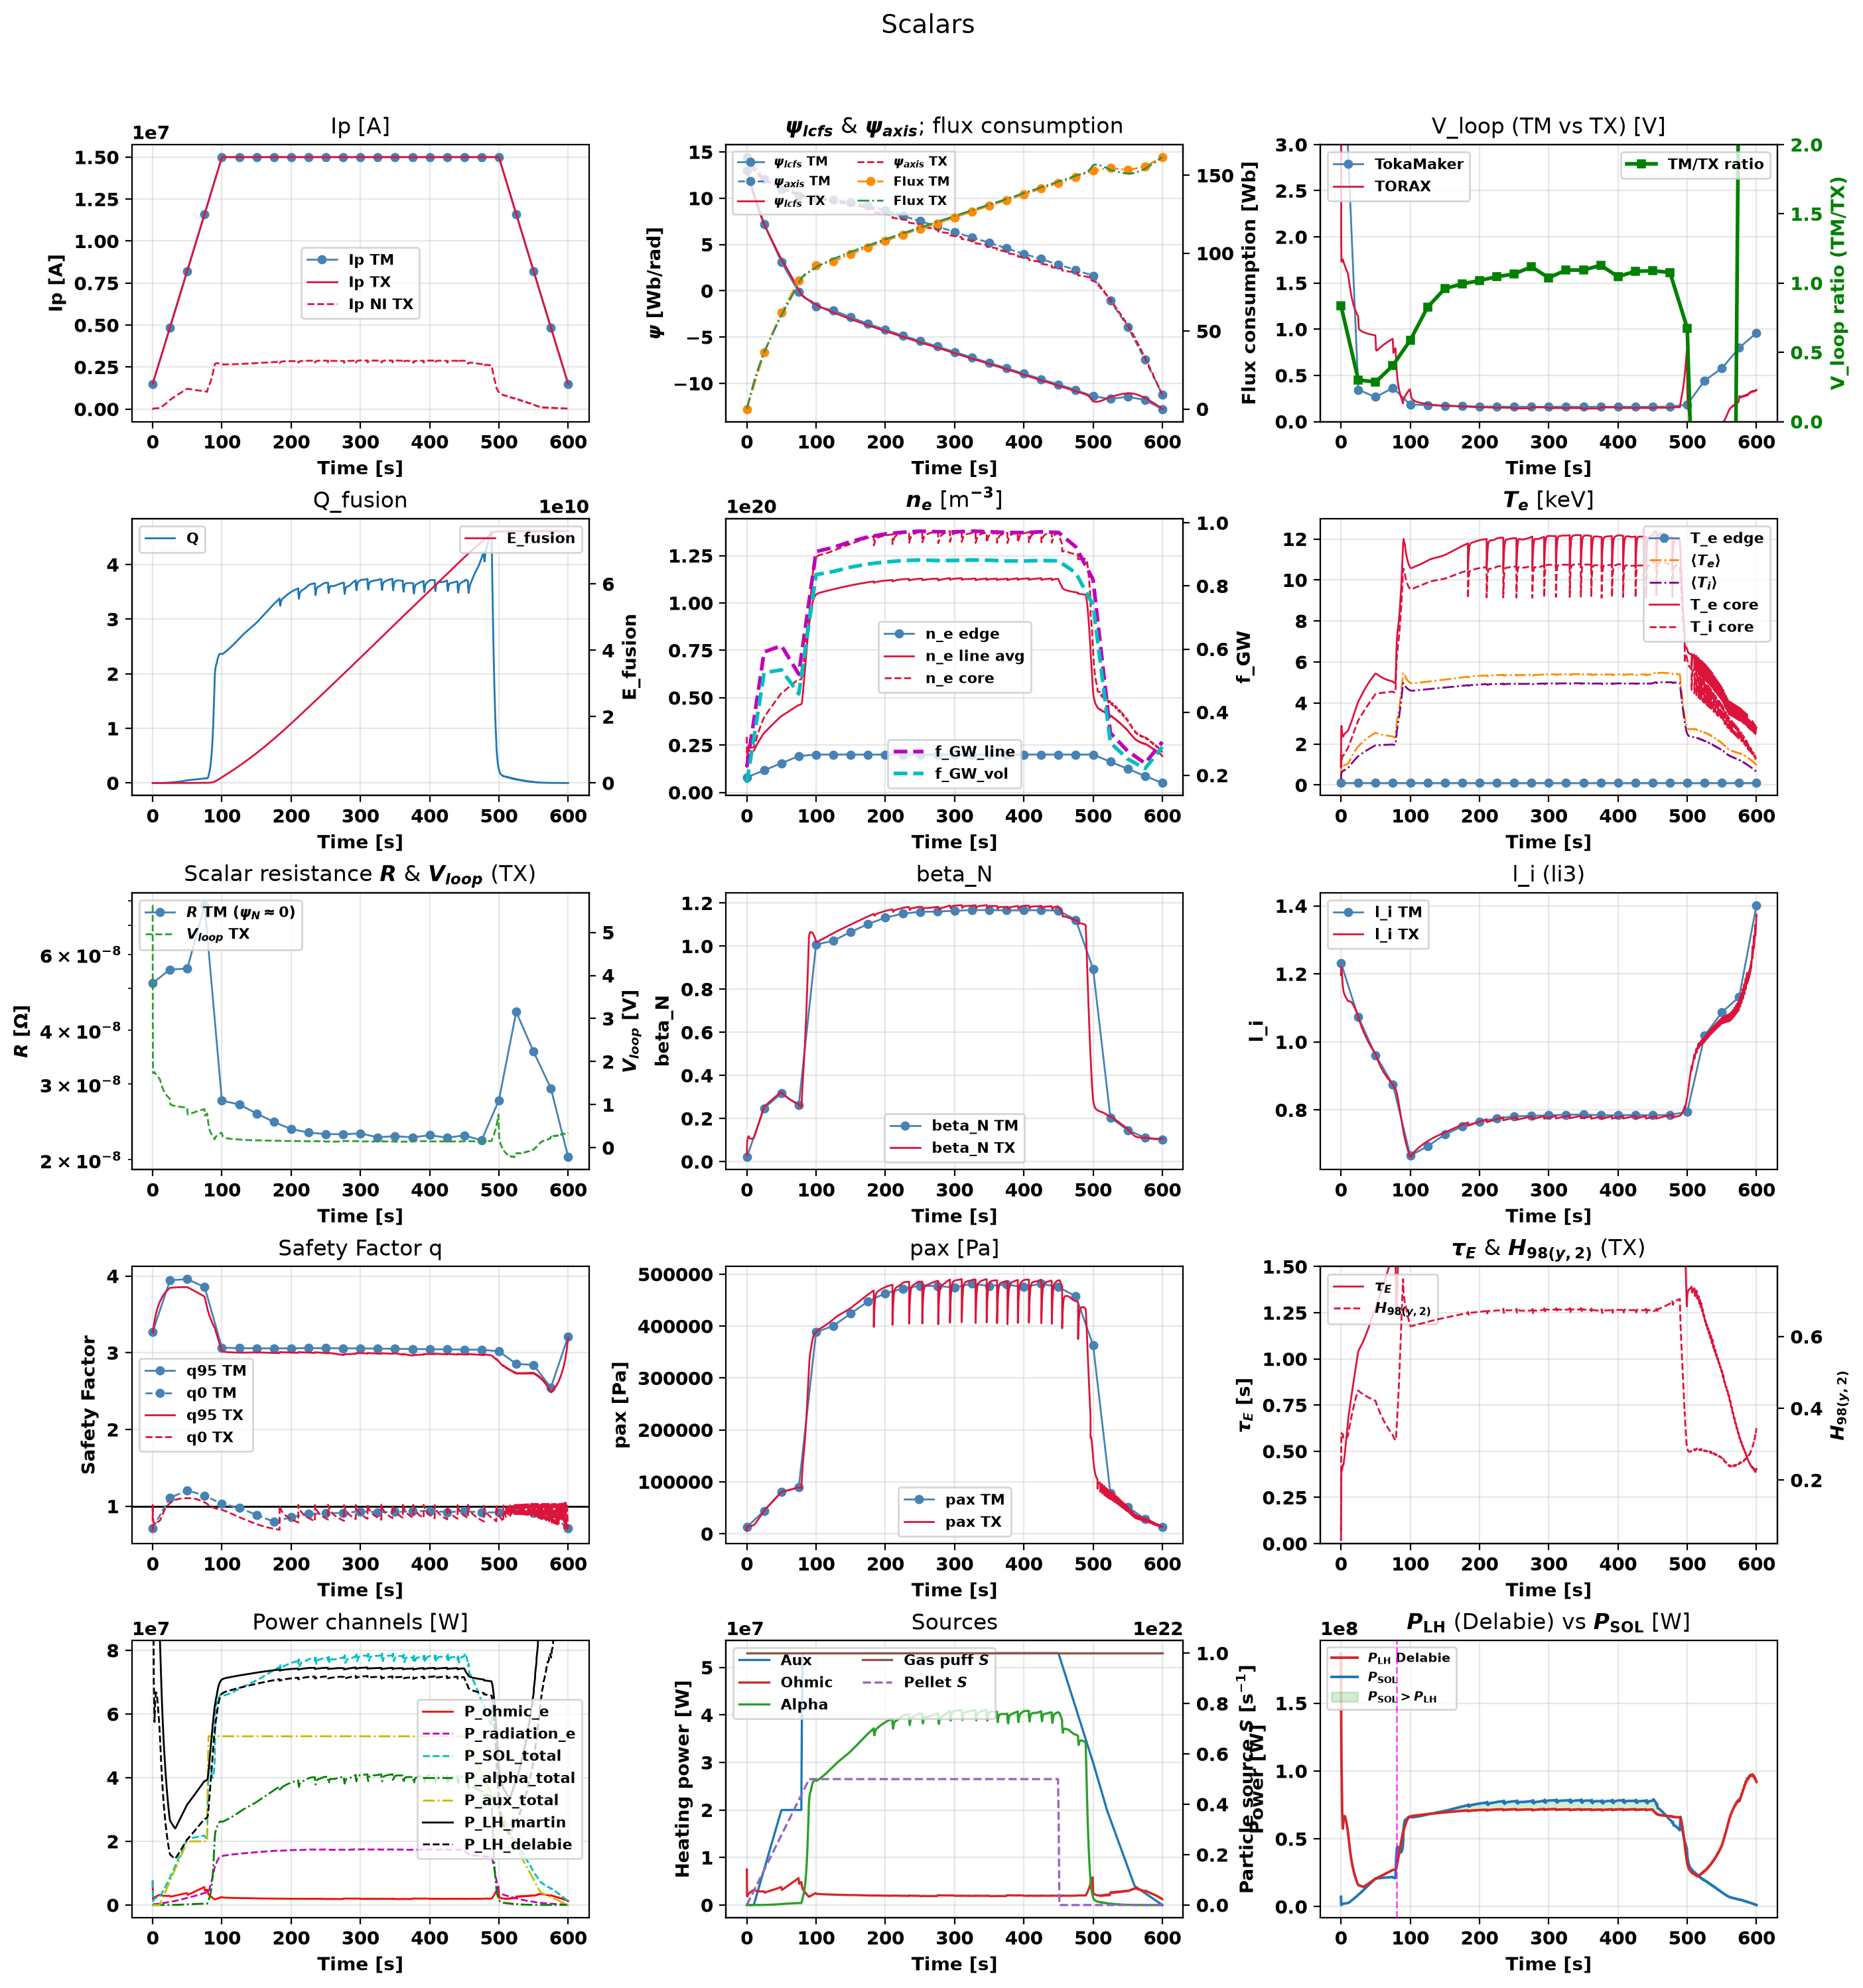

In [24]:
tmtx.plot_scalars()

The `make_movie` method produces a `.mp4` with one frame per TokaMaker solve time. The `speed_factor` input (default `1`) changes the playback speed relative to realtime, higher `speed_factor` will make the movie shorter, smaller will make the movie longer, `speed_factor=1` will make the movie take realtime, or 1 frame/equilibria per second, whichever is faster.

In [25]:
tmtx.make_movie(notebook_mode=True, speed_factor=20)

In [26]:
_ = tmtx.summary()


  TokaMaker_TORAX Physics Summary
  Q_max                           4.613
  Q_max_time                      489.3
  Q_flattop_avg                   3.515
  E_fusion_total_MJ               7.59e+04
  beta_N_max                      1.19
  H98_max                         0.7599
  H98_flattop_avg                 0.6652
  T_e_core_max_keV                12.38
  T_i_core_max_keV                10.94
  n_e_line_avg_max                1.131e+20
  f_GW_max                        0.9738
  q95_min                         2.546
  q0_min                          0.7082
  flux_consumed_Wb                161.7
  P_fusion_max_MW                 205.4
  P_ohmic_max_MW                  7.526
  l_i_flattop_avg                 0.772
  vloop_tx_flattop_avg_V          0.1642



The evolution plots, `plot_lcfs_evolution` and `plot_profile_evolution`, show traces at different times throughout the pulse where color encodes time. Both have a `one_plot` argument (default `False`) that combines all phases into one figure. When `one_plot=False` a separate plot is produced for each phase of the pulse (ramp-up, flattop, ramp-down), or whichever subset occurs in the simulation.

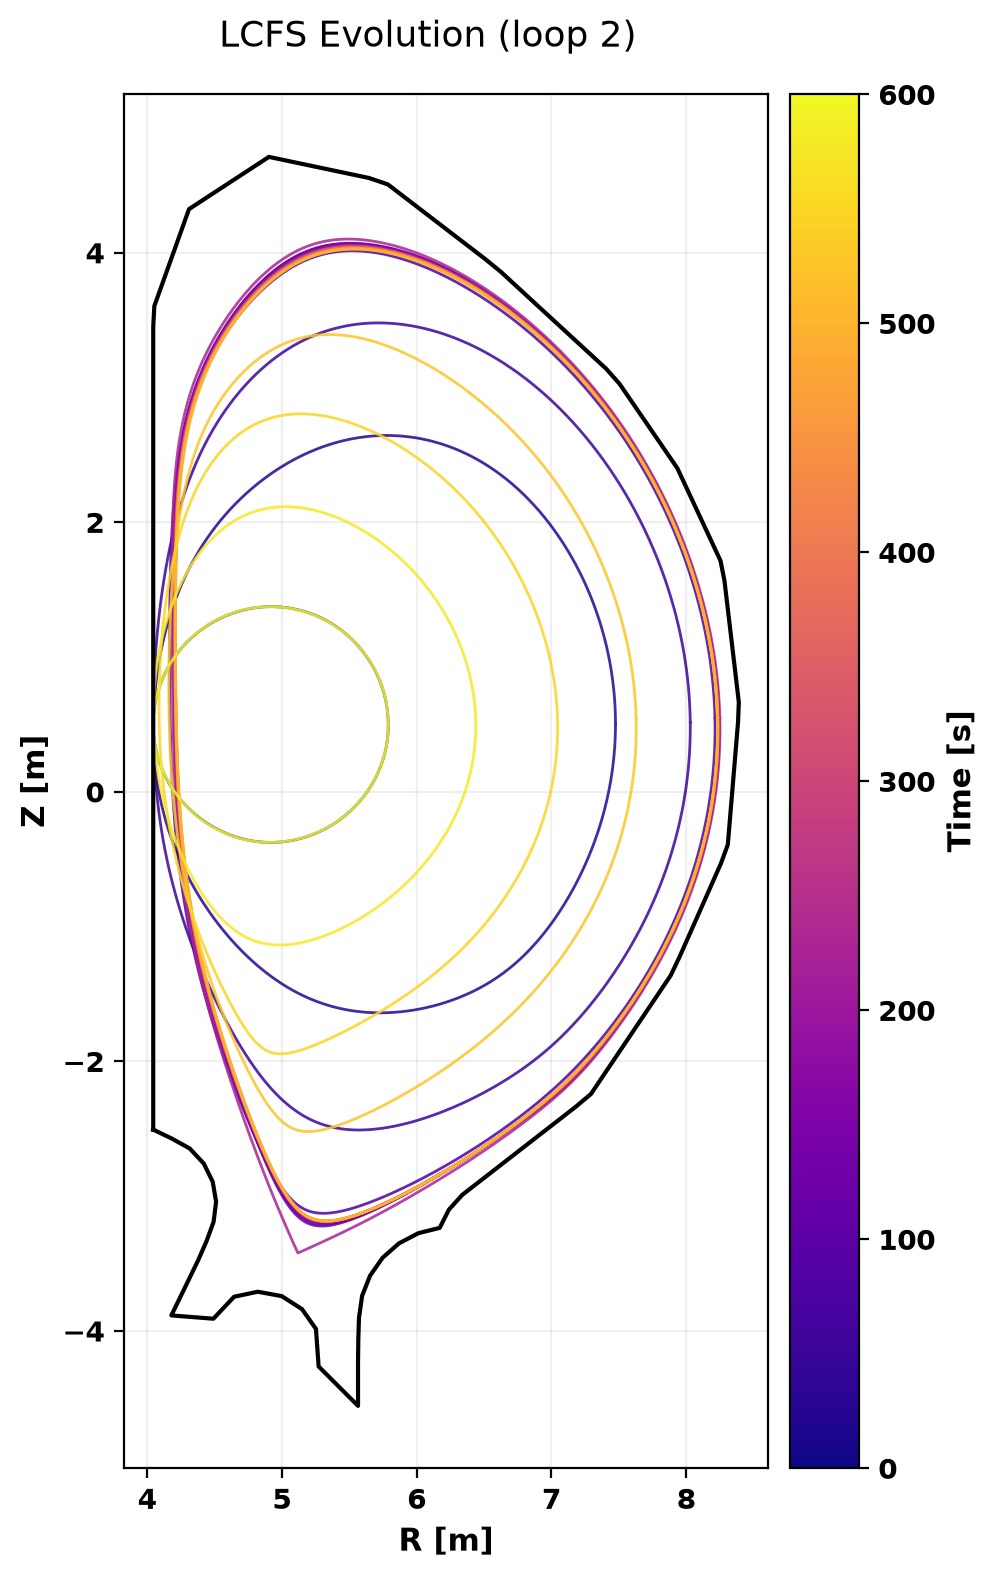

In [27]:
tmtx.plot_lcfs_evolution(one_plot=True)

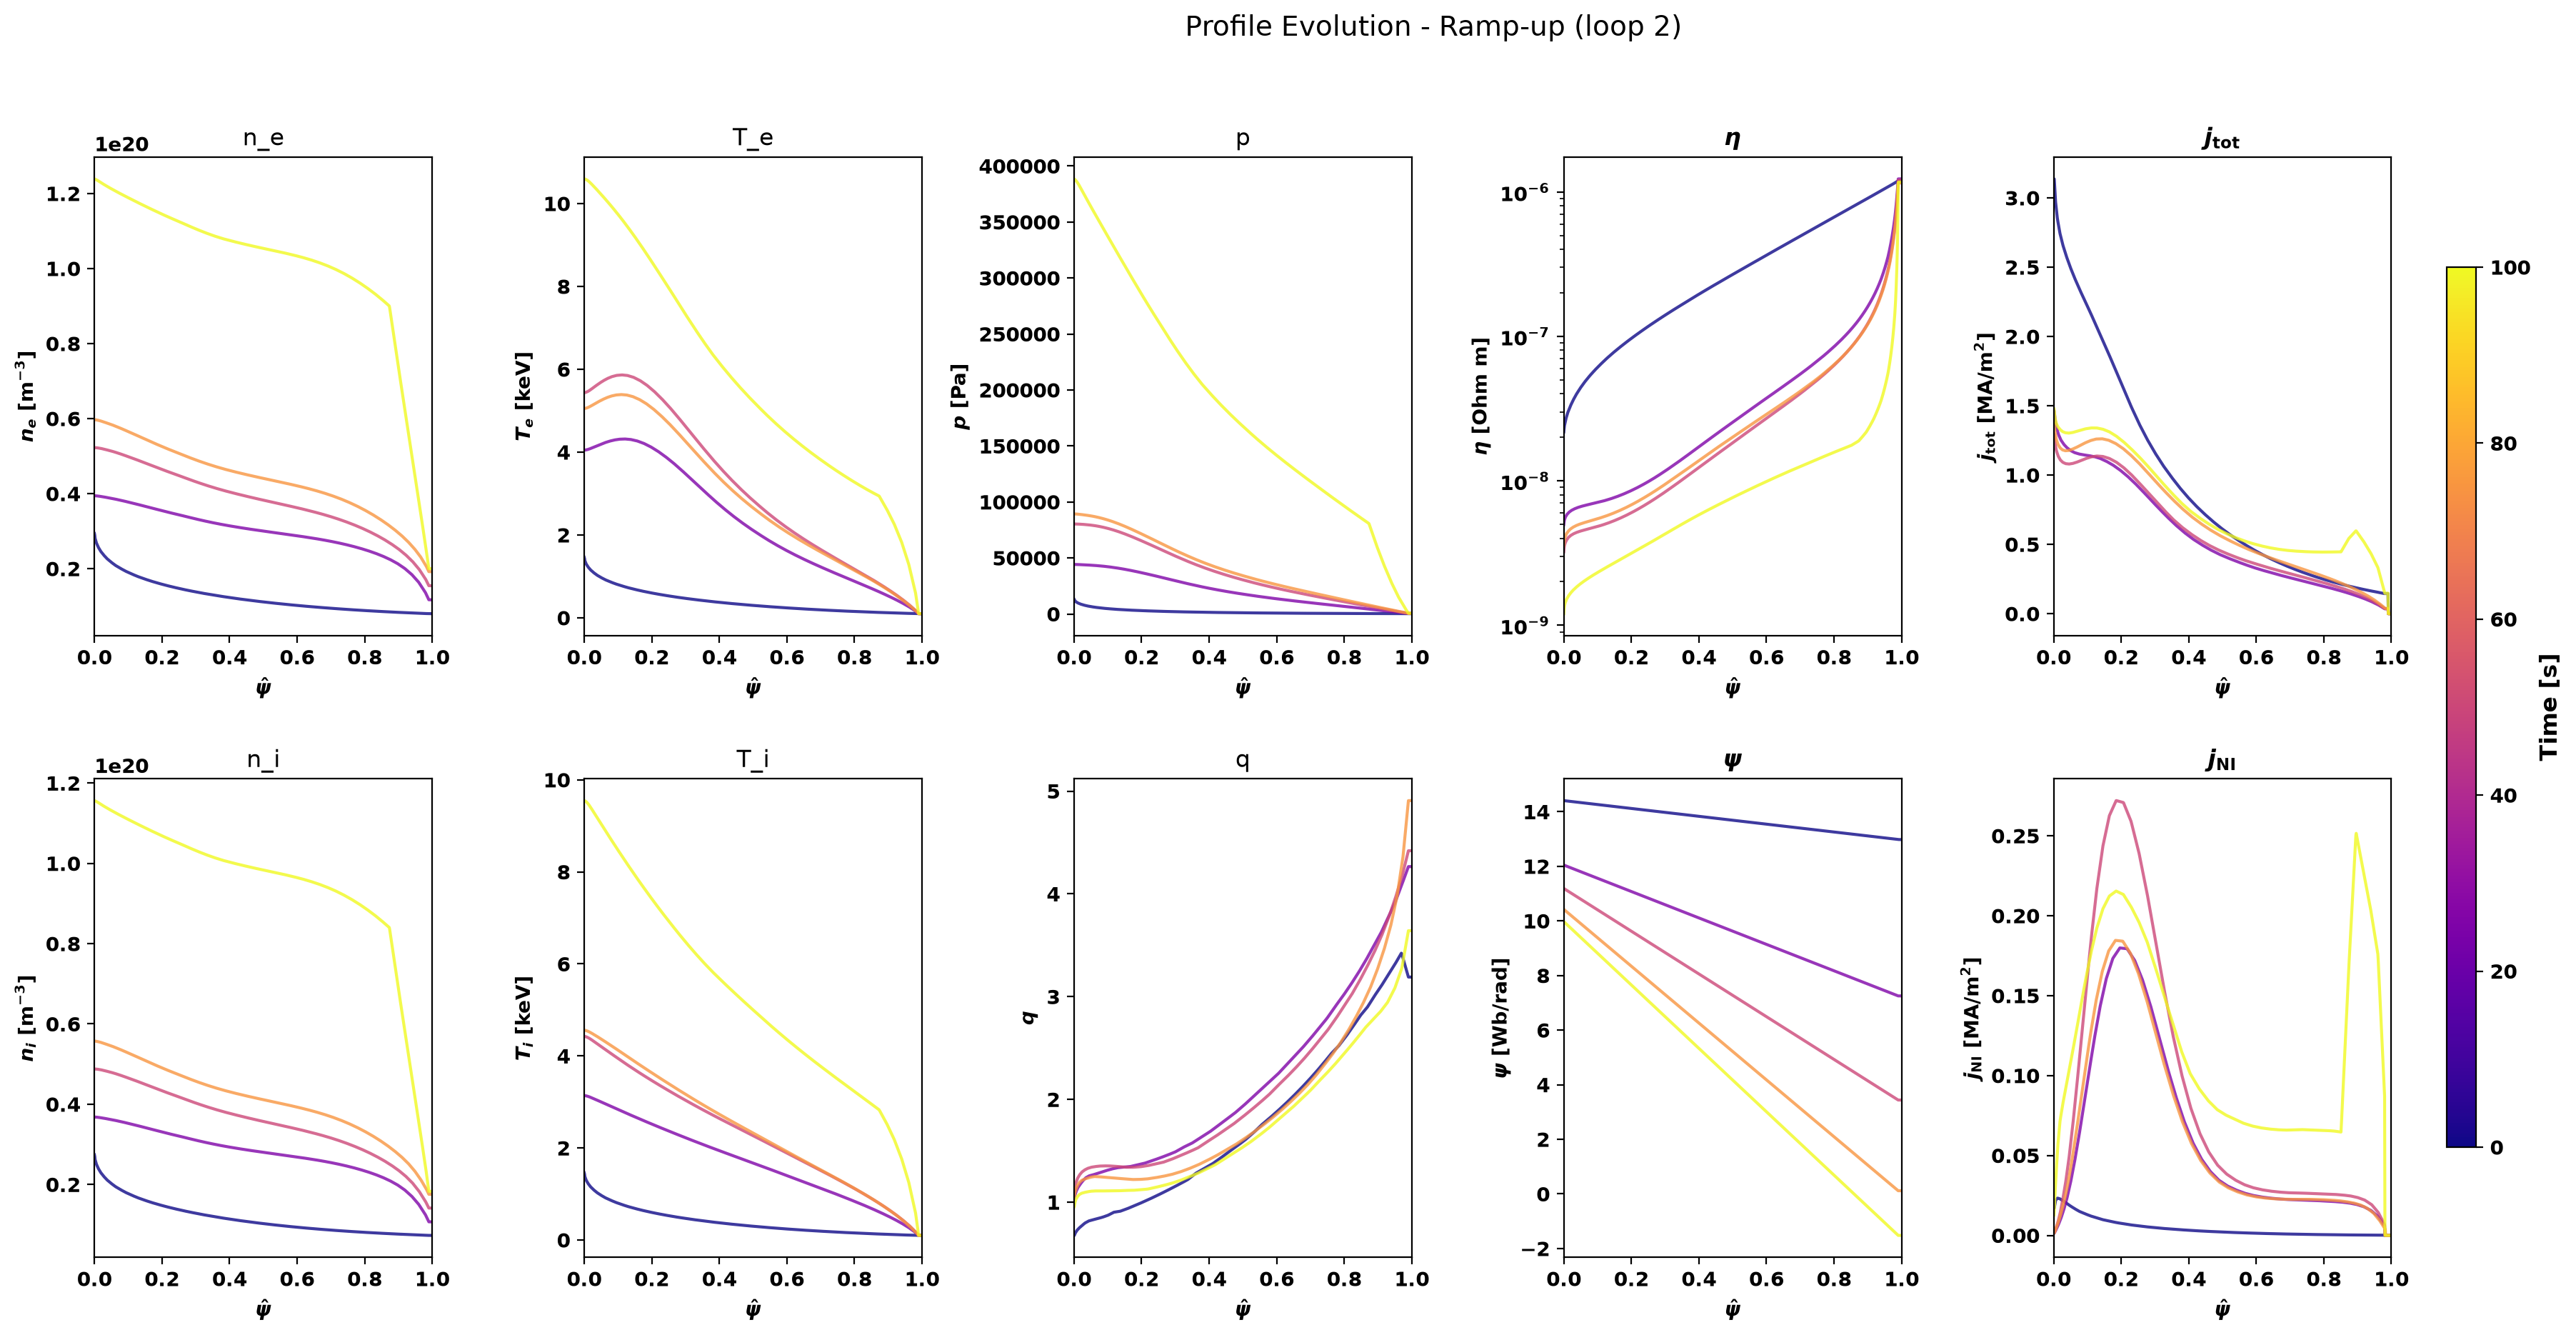

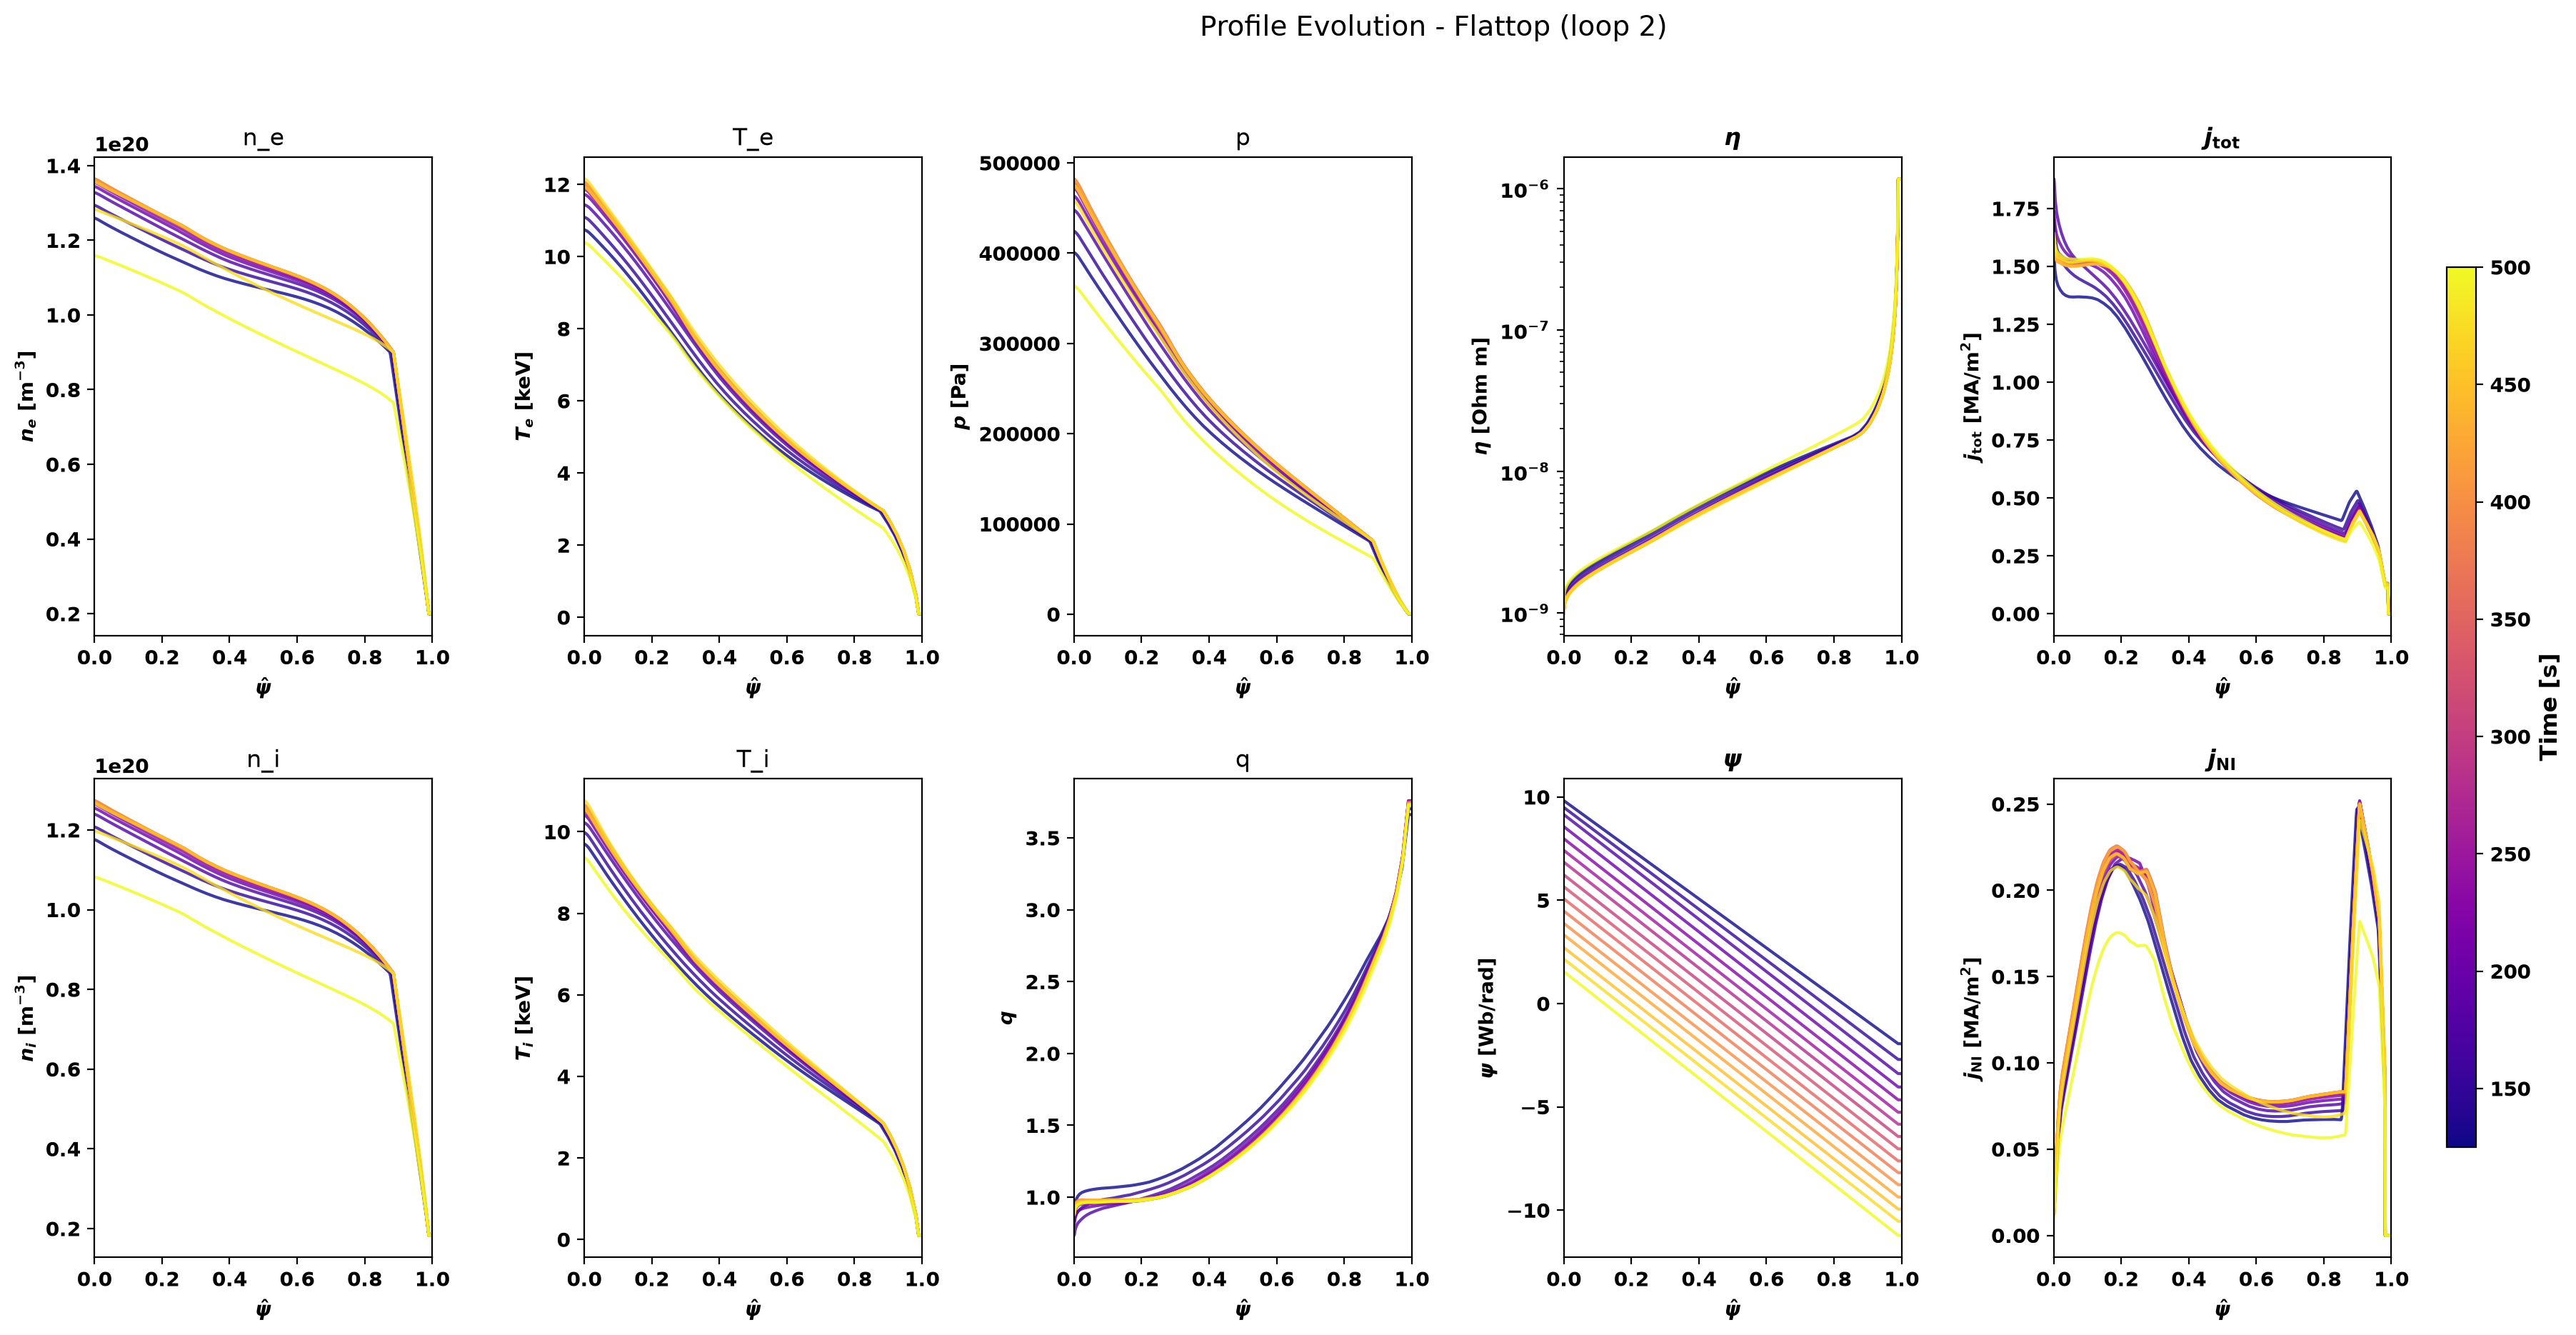

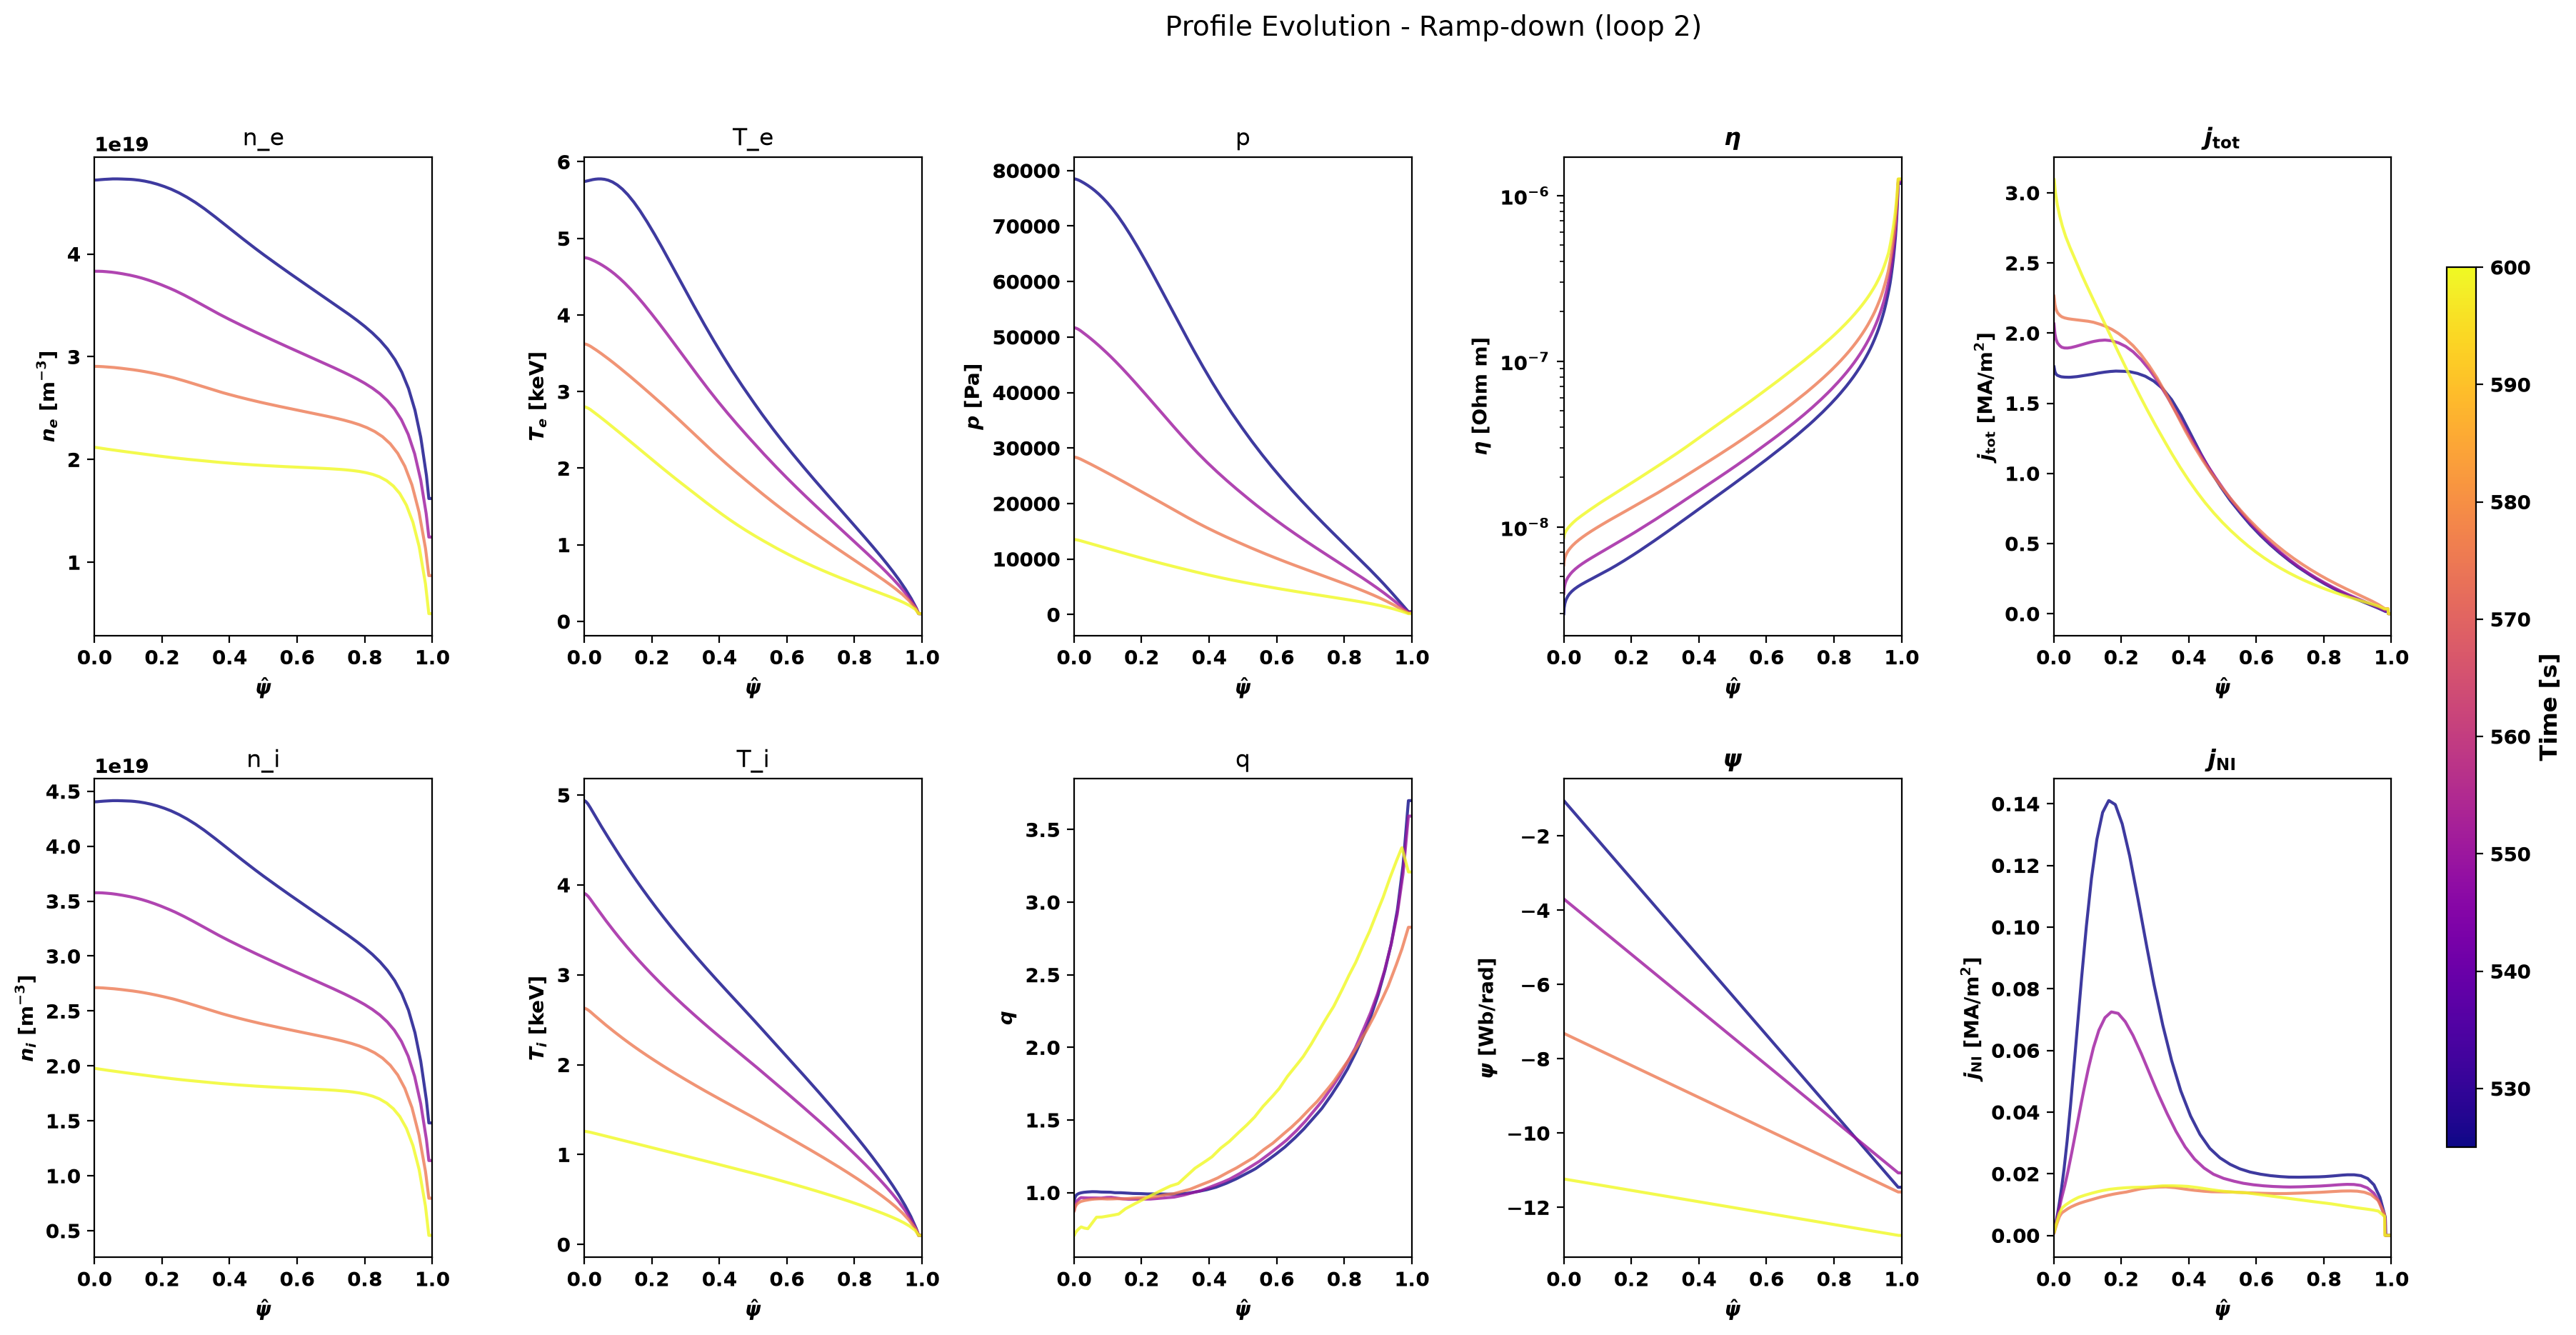

In [28]:
tmtx.plot_profile_evolution()

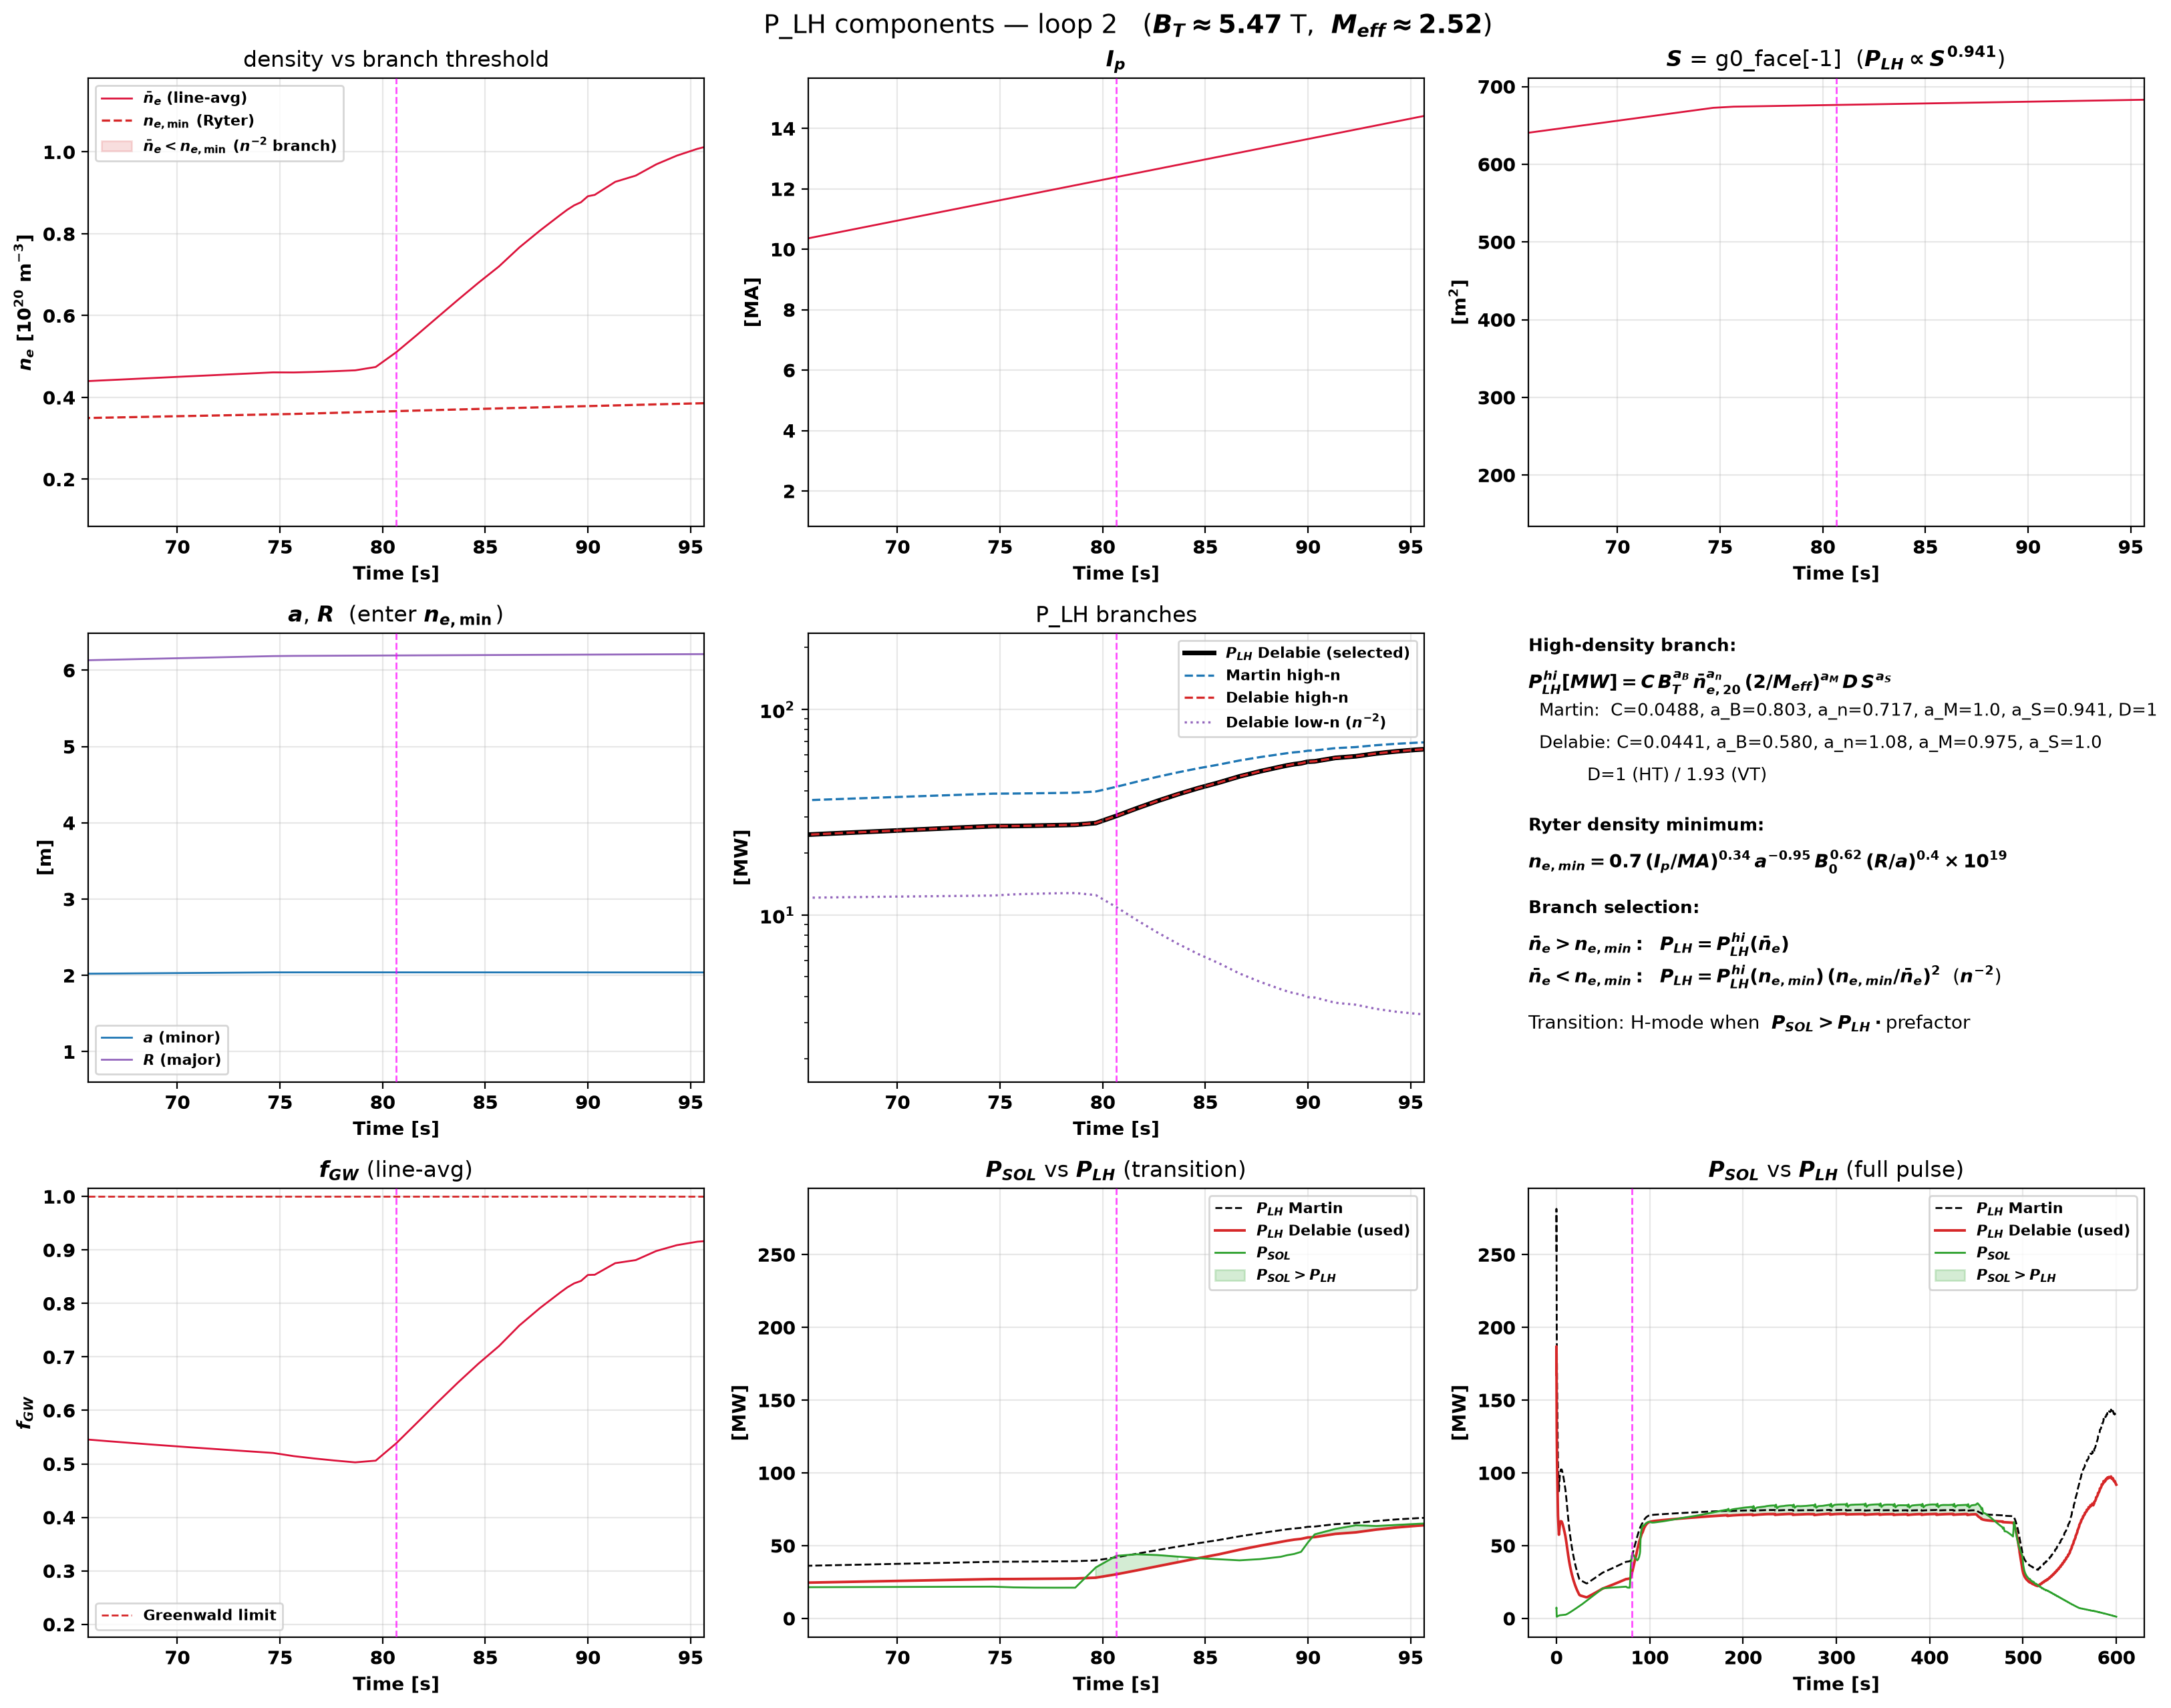

In [29]:
tmtx.plot_PLH_components()

## Disruptivity-proxy values

- **`f_GW`, `f_GW_vol`** : Greenwald density fraction (line-averaged, volume-averaged), n / n_Greenwald where n_Greenwald = Ip / (pi a^2). Limit: f_GW = 1.
- **`DL_Maris`** : Maris density/radiation limit (edge collisionality x edge beta x q_star), normalized by its semi-empirical threshold. Limit: DL_Maris = 1.
- **`troyon_margin`** : beta_N normalized against the Troyon no-wall beta limit (4 * l_i), which scales with current-profile peaking rather than being a fixed number. Limit: troyon_margin = 1.
- **`q95_margin`** : 2 / q95, inverted so lower q95 (more dangerous) still reads as a higher margin. Limit: q95_margin = 1, i.e. q95 ~ 2 (the low-q disruption boundary).
- **`q0_margin`** : 1 / q0, inverted the same way. Limit: q0_margin = 1, i.e. q0 = 1 (sawtooth/kink onset, not itself a hard disruption boundary).

All five are normalized so 1.0 marks the limit and values above 1.0 mean the pulse has crossed it, regardless of the underlying quantity's natural direction or units.

In [ ]:
class DisruptivityLimits:
    r'''! Holds the disruptivity-proxy limits computed for one TokaMaker_TORAX run, along
    with nice printing and plotting, so a compute_limits() call hands back one
    self-contained object rather than scattering attributes onto tmtx.
    '''
    def __init__(self, tm_times):
        self._tm_times = np.asarray(tm_times)
        self._all_limits = {}

    def add_limit(self, name, label, y, limit):
        r'''! Adds a new limit to the collection.
        @param name Unique identifier for the limit.
        @param label Human-readable label for the limit.
        @param y Array of limit values over time.
        @param limit The threshold value for the limit.
        '''
        y = np.asarray(y)
        i_peak = int(np.argmax(y))
        entry = {'label': label, 'y': y, 'limit': limit,
                  'peak': float(y[i_peak]), 'peak_time': float(self._tm_times[i_peak])}
        self._all_limits[name] = entry
        return entry

    def _print_limits(self):
        r'''! Print a summary of all limits, their peak values, and whether they exceed the limit.'''
        print('tm_times [s]:', np.round(self._tm_times, 1))
        for entry in self._all_limits.values():
            print(f'{entry["label"]:14s} {np.array2string(entry["y"], precision=3, max_line_width=200)}')

        print()
        print('=======================================================')
        print('  Disruptivity-Proxy Limits  (>1.0 = past the limit)')
        print('=======================================================')
        for entry in self._all_limits.values():
            print(f'  {entry["label"]:16s} peak={entry["peak"]:.3f}  at t={entry["peak_time"]:.0f}s  limit={entry["limit"]:.1f} ')
        print('=======================================================')

    def _plot_on(self, ax, keys, yscale, title):
        r'''! Plot a subset of limits on a given axis.
        @param ax Matplotlib axis to plot on.
        @param keys List of _all_limits keys to include.
        @param yscale 'linear' or 'log'.
        @param title Figure title.
        '''
        for key in keys:
            entry = self._all_limits[key]
            ax.plot(self._tm_times, entry['y'], 'o-', markersize=3, label=entry['label'])
        ax.axhline(1.0, color='r', ls='--', label='limit')
        ax.set_yscale(yscale)
        ax.set_xlabel('time [s]')
        ax.set_title(title)
        ax.grid(alpha=0.3, which='both')

    def _plot_subset(self, keys, title, scale='linear'):
        """Plot a chosen subset of limits (by their _all_limits key) on one figure.
        @param keys List of _all_limits keys to include.
        @param title Figure title.
        @param scale 'linear', 'log', or 'both'. Linear reads naturally near 1.0 (where
        most of these actually live) but flattens DL_Maris (two orders of magnitude
        smaller) to nothing. Log shows every trace's own shape but compresses
        differences near 1.0. Same shared "1.0 = limit" dashed line either way.
        """
        if scale not in ('linear', 'log', 'both'):
            raise ValueError("scale must be 'linear', 'log', or 'both'")

        if scale == 'both':
            fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(14, 5))
            self._plot_on(ax_lin, keys, 'linear', 'linear scale')
            self._plot_on(ax_log, keys, 'log', 'log scale')
            ax_lin.set_ylabel('margin (>1.0 = past the limit)')
            ax_log.legend()
        else:
            fig, ax = plt.subplots(figsize=(8, 5))
            self._plot_on(ax, keys, scale, f'{scale} scale')
            ax.set_ylabel('margin (>1.0 = past the limit)')
            ax.legend()

        fig.suptitle(title)
        plt.tight_layout()
        plt.show()

    #### Show plots gives all the limits together, option for linear/log scales or both ####
    def _show_plots(self, scale='both'):
        self._plot_subset(list(self._all_limits.keys()), 'Disruptivity-proxy limits', scale=scale)

    #### Individual limit plots for convenience, each on one figure with linear/log/both option ####
    def _plot_greenwald(self, scale='linear'):
        self._plot_subset(['f_GW', 'f_GW_vol'], 'Greenwald density fraction', scale=scale)

    def _plot_maris(self, scale='linear'):
        self._plot_subset(['DL_Maris'], 'Maris density/radiation limit', scale=scale)

    def _plot_troyon(self, scale='linear'):
        self._plot_subset(['troyon_margin'], 'Troyon beta limit margin', scale=scale)

    def _plot_q95(self, scale='linear'):
        self._plot_subset(['q95_margin'], 'q95 margin', scale=scale)

    def _plot_q0(self, scale='linear'):
        self._plot_subset(['q0_margin'], 'q0 margin', scale=scale)


def compute_limits(tmtx):
    r'''!Compute disruptivity-proxy limits for a TokaMaker_TORAX run and return them as a
    DisruptivityLimits object (disruptivity._all_limits for everything at once, plus one
    named attribute per limit like disruptivity._DL_maris).
    '''
    state = getattr(tmtx, 'state', tmtx._state)
    tm = np.asarray(tmtx._tm_times)

    # Greenwald density fraction: already normalized so 1.0 marks the limit
    f_GW = np.asarray(state['f_GW'])
    f_GW_vol = np.asarray(state['f_GW_vol'])

    # Maris density/radiation limit (DL26): edge collisionality x edge beta x q_star,
    # normalized so ~1 marks the limit. Edge sampled at rho=0.95 rather than the
    # separatrix, since rho=1 here is pinned to the prescribed boundary condition.
    EC = 1.60217662e-19
    MU0 = 4 * np.pi * 1e-7
    EPS0 = 8.8541878128e-12
    WARN = 0.1

    # Compute Coulomb logarithm at the plasma edge.
    def coulomb_log_edge(ne, Te):
        dl = 7430 * np.sqrt(Te / ne)
        return np.log(12 * np.pi * ne * dl**3)

    # Compute normalized safety factor.
    def q_star(Bt0, R0, eps, kappa, Ip):
        return np.abs((2 * np.pi / MU0) * Bt0 * R0 * eps**2 * ((1 + kappa**2) / 2) / Ip)

    # Compute normalized edge collisionality
    def collisionality_edge(ne, Te, qs, R0, eps):
        return (EC**4 / (4 * np.pi * EPS0**2)) * coulomb_log_edge(ne, Te) * ne * qs * R0 * eps**(-1.5) * (2 * EC * Te)**(-2)

    # Compute normalized edge plasma pressure (beta).
    def beta_edge(ne, Te, Bt0, R0, a0, Ip):
        bp = MU0 * Ip / (2 * np.pi * a0)
        bt = Bt0 * R0 / (R0 + a0)
        return 4 * MU0 * ne * Te * EC * (bt**2 + bp**2)**(-1)

    def dl26_metric(ne, Te, Bt0, R0, a0, kappa, Ip):
        r'''! Compute the Maris density/radiation limit (DL26) metric.
        @param ne Edge electron density [m^-3].
        @param Te Edge electron temperature [eV].
        @param Bt0 Toroidal magnetic field at the plasma center [T].
        @param R0 Major radius of the plasma [m].
        @param a0 Minor radius of the plasma [m].
        @param kappa Plasma elongation.
        @param Ip Plasma current [A].
        @return The DL26 metric value.
        '''
        eps = a0 / R0
        qs = q_star(Bt0, R0, eps, kappa, Ip)
        return collisionality_edge(ne, Te, qs, R0, eps) * beta_edge(ne, Te, Bt0, R0, a0, Ip) * qs

    pf = tmtx._data_tree['profiles'].to_dataset()
    ne_arr = np.asarray(pf['n_e'])
    Te_arr = np.asarray(pf['T_e'])
    rho_dim = [d for d in pf['n_e'].dims if d != 'time'][0]
    rho = np.asarray(pf[rho_dim])
    tt = np.asarray(pf['time'])
    j_edge = int(np.argmin(np.abs(rho - 0.95)))

    dl26_Maris = []
    for i, t in enumerate(tm):
        ne_e = float(np.interp(t, tt, ne_arr[:, j_edge]))
        Te_e = float(np.interp(t, tt, Te_arr[:, j_edge])) * 1e3   # keV -> eV
        R0_i = float(state['R0_mag'][i]); a0 = float(state['a'][i]); Bt0 = abs(float(state['B0'][i]))
        kappa_i = float(state['kappa'][i]); Ip_i = abs(float(state['Ip'][i]))
        dl26_Maris.append(dl26_metric(ne_e, Te_e, Bt0, R0_i, a0, kappa_i, Ip_i) / WARN)
    dl26_Maris = np.array(dl26_Maris)

    # Troyon no-wall beta limit: beta_N compared against a curve (4 * l_i) rather than a
    # fixed number, since the beta a plasma can sustain scales with current-profile peaking.
    troyon_margin = np.asarray(state['beta_N_tx']) / (4.0 * np.asarray(state['l_i_tm']))

    # q95 and q0: lower is more dangerous, so these are inverted (limit / value) to keep
    # the same ">1 means past the limit" reading as everything above.
    q95_margin = 2.0 / np.asarray(state['q95'])
    q0_margin = 1.0 / np.asarray(state['q0_tm'])

    disruptivity = DisruptivityLimits(tm)
    disruptivity._DL_greenwald = disruptivity.add_limit('f_GW', 'f_GW (line)', f_GW, 1.0)
    disruptivity._DL_greenwald_vol = disruptivity.add_limit('f_GW_vol', 'f_GW (vol)', f_GW_vol, 1.0)
    disruptivity._DL_maris = disruptivity.add_limit('DL_Maris', 'DL_Maris', dl26_Maris, 1.0)
    disruptivity._troyon_margin = disruptivity.add_limit('troyon_margin', 'troyon_margin', troyon_margin, 1.0)
    disruptivity._q95_margin = disruptivity.add_limit('q95_margin', 'q95_margin', q95_margin, 1.0)
    disruptivity._q0_margin = disruptivity.add_limit('q0_margin', 'q0_margin', q0_margin, 1.0)
    return disruptivity

In [73]:
disruptivity = compute_limits(tmtx)
disruptivity._print_limits()

tm_times [s]: [  0.  25.  50.  75. 100. 125. 150. 175. 200. 225. 250. 275. 300. 325.
 350. 375. 400. 425. 450. 475. 500. 525. 550. 575. 600.]
f_GW (line)    [0.226 0.591 0.611 0.52  0.909 0.922 0.941 0.955 0.965 0.97  0.974 0.972 0.971 0.974 0.972 0.97  0.969 0.972 0.97  0.924 0.82  0.334 0.277 0.238 0.306]
f_GW (vol)     [0.176 0.525 0.534 0.458 0.836 0.846 0.86  0.87  0.876 0.88  0.882 0.881 0.881 0.883 0.882 0.879 0.879 0.881 0.88  0.841 0.74  0.303 0.252 0.221 0.29 ]
DL_Maris       [0.012 0.021 0.019 0.025 0.015 0.015 0.015 0.015 0.015 0.015 0.015 0.015 0.015 0.015 0.015 0.015 0.015 0.015 0.015 0.016 0.014 0.011 0.007 0.006 0.016]
troyon_margin  [0.006 0.059 0.084 0.076 0.383 0.374 0.371 0.372 0.375 0.377 0.377 0.376 0.377 0.378 0.377 0.377 0.377 0.377 0.377 0.363 0.285 0.051 0.035 0.025 0.019]
q95_margin     [0.613 0.52  0.519 0.536 0.662 0.665 0.666 0.666 0.666 0.666 0.666 0.67  0.67  0.668 0.669 0.672 0.672 0.67  0.671 0.672 0.677 0.732 0.733 0.805 0.625]
q0_margin      [1.4   0